In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 145.2 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
import mne

In [ ]:
import os
import glob
import json
import numpy as np
import pandas as pd
import mne

# DATASET_DIR = "/content/ds007262"
DATASET_DIR = "/content/drive/MyDrive/ds007262"
OUT_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
os.makedirs(OUT_DIR, exist_ok=True)

VALID_LABELS = [
    "0.6-1.5",
    "1.5-2.4",
    "2.4-3.3",
    "3.3-4.2",
    "4.2-5.1",
    "5.1-6.0",
    "6.0-6.9",
]
LABEL_MAP = {lab: i for i, lab in enumerate(VALID_LABELS)}

def find_subjects(dataset_dir: str):
    subs = sorted(glob.glob(os.path.join(dataset_dir, "sub-*")))
    return [os.path.basename(s) for s in subs if os.path.isdir(s)]

def load_subject_files(dataset_dir: str, sub_id: str):
    eeg_dir = os.path.join(dataset_dir, sub_id, "eeg")
    vhdr = glob.glob(os.path.join(eeg_dir, "*_eeg.vhdr"))
    events_tsv = glob.glob(os.path.join(eeg_dir, "*_events.tsv"))
    channels_tsv = glob.glob(os.path.join(eeg_dir, "*_channels.tsv"))

    if len(vhdr) == 0 or len(events_tsv) == 0:
        return None, None, None

    return vhdr[0], events_tsv[0], channels_tsv[0] if len(channels_tsv) else None

def preprocess_raw(vhdr_path: str):
    raw = mne.io.read_raw_brainvision(vhdr_path, preload=True, verbose=False)

    # Keep EEG only. This should drop D1-D5.
    raw = raw.copy().pick("eeg")

    # From our debugging on this dataset: scale counts -> volts
    raw.apply_function(lambda x: x * 1e-6)

    # Basic preprocessing
    raw.filter(1, 40, verbose=False)
    # raw.filter(2, 30, verbose=False)
    raw.notch_filter(60, verbose=False)
    raw.set_eeg_reference("average", verbose=False)

    return raw

def get_clean_trial_events(events_path: str):
    events = pd.read_csv(events_path, sep="\t")

    # Real arithmetic trials only:
    # - arithmetic marker stream
    # - duration ~ 6 seconds
    # - not tutorial
    # - valid difficulty label
    clean = events[
        (events["marker_stream"] == "arithmetic-Markers") &
        (events["duration"] > 5) &
        (events["istutorial"] != True) &
        (events["difficulty_range"].isin(VALID_LABELS))
    ].copy()

    clean = clean.sort_values("onset").reset_index(drop=True)
    return clean, events

def extract_trials(raw, clean_events: pd.DataFrame, sub_id: str):
    sfreq = raw.info["sfreq"]
    data = raw.get_data()  # (channels, time)
    n_channels = data.shape[0]
    win_samples = int(6 * sfreq)

    X = []
    y = []
    onset_sec = []
    kept_rows = []

    for idx, row in clean_events.iterrows():
        start = int(row["onset"] * sfreq)
        end = start + win_samples

        if end > data.shape[1]:
            continue

        seg = data[:, start:end]

        # Expect fixed shape: (19, 1500)
        if seg.shape != (n_channels, win_samples):
            continue

        X.append(seg.astype(np.float32))
        y.append(LABEL_MAP[row["difficulty_range"]])
        onset_sec.append(float(row["onset"]))
        kept_rows.append(idx)

    if len(X) == 0:
        return None

    X = np.stack(X)                    # (trials, channels, time)
    y = np.array(y, dtype=np.int64)
    onset_sec = np.array(onset_sec, dtype=np.float32)

    # Per-trial quality stats: save, don't hard-delete
    trial_std = np.std(X, axis=(1, 2))
    trial_max = np.max(np.abs(X), axis=(1, 2))

    # Conservative masks for later experimentation
    keep_std95 = trial_std < np.percentile(trial_std, 95)
    keep_max95 = trial_max < np.percentile(trial_max, 95)

    # Per-channel variance profile
    channel_var = np.var(X, axis=2)                    # (trials, channels)
    mean_var_per_channel = channel_var.mean(axis=0)   # (channels,)

    return {
        "X": X,
        "y": y,
        "onset_sec": onset_sec,
        "kept_event_rows": np.array(kept_rows, dtype=np.int64),
        "trial_std": trial_std.astype(np.float32),
        "trial_max": trial_max.astype(np.float32),
        "keep_std95": keep_std95,
        "keep_max95": keep_max95,
        "mean_var_per_channel": mean_var_per_channel.astype(np.float32),
        "ch_names": np.array(raw.ch_names, dtype=object),
        "sfreq": np.array([sfreq], dtype=np.float32),
        "sub_id": np.array([sub_id], dtype=object),
    }

participants_path = os.path.join(DATASET_DIR, "participants.tsv")
participants_df = pd.read_csv(participants_path, sep="\t") if os.path.exists(participants_path) else None

subjects = find_subjects(DATASET_DIR)
print("Found subjects:", subjects)

summary_rows = []

for sub_id in subjects:
    print(f"\n=== Processing {sub_id} ===")
    vhdr_path, events_path, channels_path = load_subject_files(DATASET_DIR, sub_id)

    if vhdr_path is None:
        print("Missing EEG or events file, skipping.")
        summary_rows.append({"sub_id": sub_id, "status": "missing_files"})
        continue

    try:
        raw = preprocess_raw(vhdr_path)
        clean_events, all_events = get_clean_trial_events(events_path)
        result = extract_trials(raw, clean_events, sub_id)

        if result is None:
            print("No valid trials extracted.")
            summary_rows.append({"sub_id": sub_id, "status": "no_valid_trials"})
            continue

        out_path = os.path.join(OUT_DIR, f"{sub_id}_arithmetic_6s_eeg.npz")
        np.savez_compressed(out_path, **result)

        summary = {
            "sub_id": sub_id,
            "status": "ok",
            "n_trials": int(result["X"].shape[0]),
            "n_channels": int(result["X"].shape[1]),
            "n_time": int(result["X"].shape[2]),
            "sfreq": float(result["sfreq"][0]),
            "label_counts": dict(zip(*np.unique(result["y"], return_counts=True))),
        }

        if participants_df is not None and "participant_id" in participants_df.columns:
            row = participants_df[participants_df["participant_id"] == sub_id]
            if len(row):
                for col in row.columns:
                    summary[col] = row.iloc[0][col]

        summary_rows.append(summary)
        print("Saved:", out_path)
        print("Trials:", summary["n_trials"], "| shape:", result["X"].shape)

    except Exception as e:
        print("ERROR:", e)
        summary_rows.append({"sub_id": sub_id, "status": f"error: {e}"})

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(OUT_DIR, "extraction_summary.csv")
summary_df.to_csv(summary_csv, index=False)

meta = {
    "dataset": "ds007262",
    "valid_labels": VALID_LABELS,
    "label_map": LABEL_MAP,
    "notes": [
        "EEG only",
        "6-second arithmetic trials only",
        "tutorial trials excluded",
        "UoHDataOffsetStream / dropped_samples not used as trials",
        "preprocessing: scale *1e-6, 1-40 Hz filter, 60 Hz notch, average reference",
        "per-trial quality masks saved but trials are not deleted automatically",
    ],
}
with open(os.path.join(OUT_DIR, "dataset_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("\nDone.")
print("Saved summary to:", summary_csv)
print(summary_df[["sub_id", "status"] + [c for c in ["n_trials", "n_channels", "n_time"] if c in summary_df.columns]].head())

Found subjects: ['sub-001', 'sub-003', 'sub-004', 'sub-005', 'sub-006', 'sub-007', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-018', 'sub-019', 'sub-020']

=== Processing sub-001 ===
Saved: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-001_arithmetic_6s_eeg.npz
Trials: 63 | shape: (63, 19, 1500)

=== Processing sub-003 ===
Saved: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-003_arithmetic_6s_eeg.npz
Trials: 63 | shape: (63, 19, 1500)

=== Processing sub-004 ===
Saved: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-004_arithmetic_6s_eeg.npz
Trials: 63 | shape: (63, 19, 1500)

=== Processing sub-005 ===
Saved: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-005_arithmetic_6s_eeg.npz
Trials: 63 | shape: (63, 19, 1500)

=== Processing sub-006 ===
Saved: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-006_arithmetic_6s_eeg.npz
Trials: 63 | shape: (63, 19, 1500)


Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-001_arithmetic_6s_eeg.npz


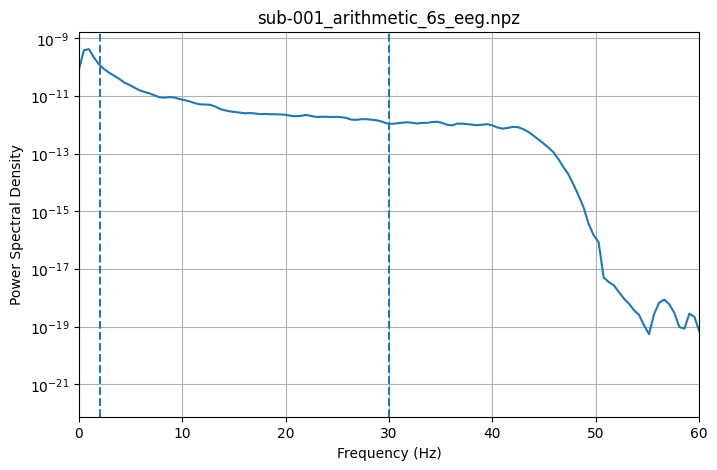

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-003_arithmetic_6s_eeg.npz


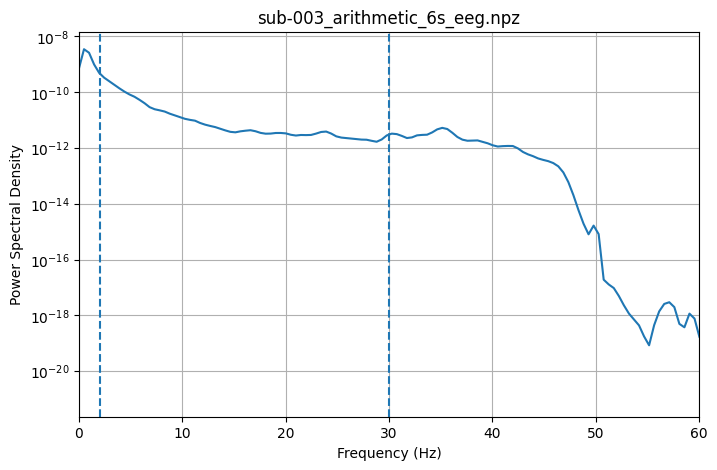

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-004_arithmetic_6s_eeg.npz


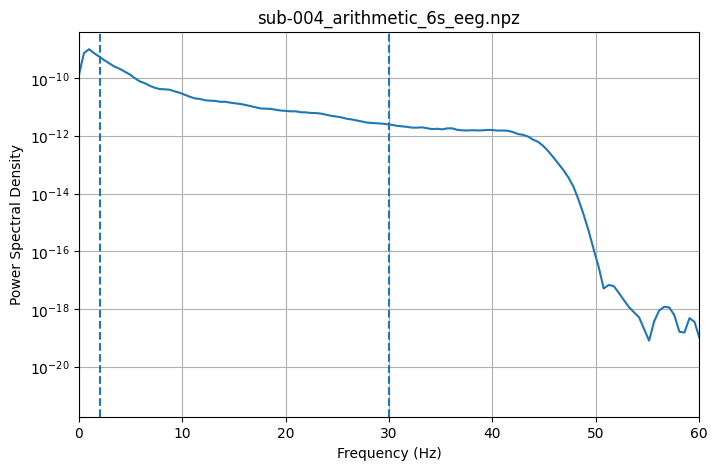

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import glob
import os

DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"

def plot_psd_subject(npz_path, max_freq=60):
    data = np.load(npz_path, allow_pickle=True)

    X = data["X"]           # (trials, channels, time)
    sfreq = float(data["sfreq"][0])

    # Flatten across trials for stability
    X_flat = X.reshape(-1, X.shape[-1])  # (trials*channels, time)

    # Compute PSD using Welch
    freqs, psd = welch(
        X_flat,
        fs=sfreq,
        nperseg=512,
        axis=-1
    )

    # Average across all signals
    psd_mean = psd.mean(axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.semilogy(freqs, psd_mean)
    plt.axvline(30, linestyle="--")  # cutoff marker
    plt.axvline(2, linestyle="--")
    plt.xlim(0, max_freq)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title(os.path.basename(npz_path))
    plt.grid(True)
    plt.show()


# ---- run on a few subjects ----
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))

for f in npz_files[:3]:  # plot first 3 subjects
    print("Plotting:", f)
    plot_psd_subject(f)

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-001_arithmetic_6s_eeg.npz


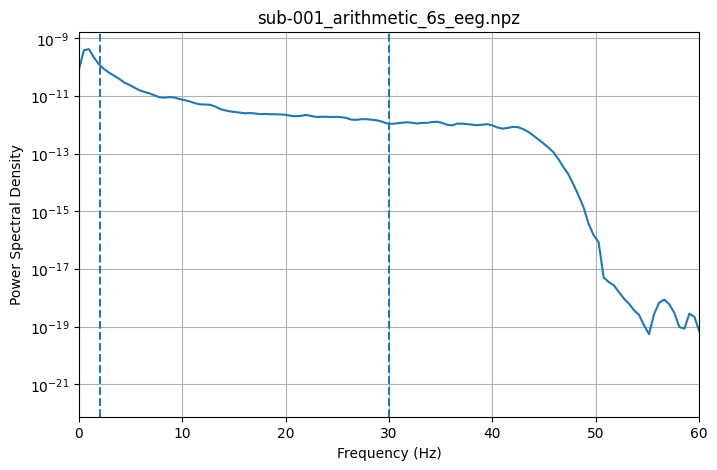

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-003_arithmetic_6s_eeg.npz


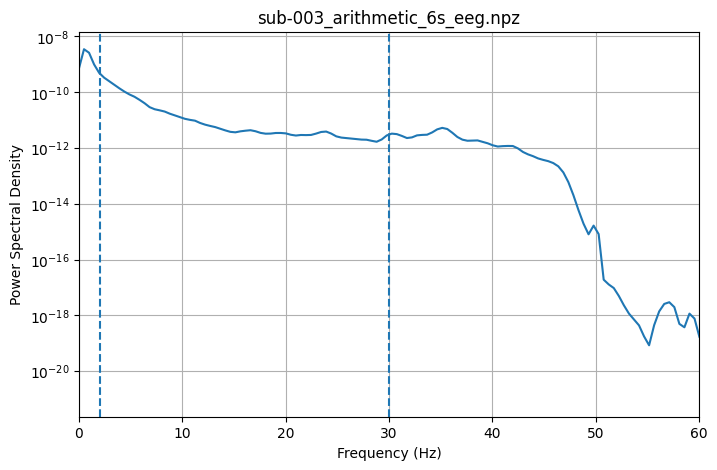

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-004_arithmetic_6s_eeg.npz


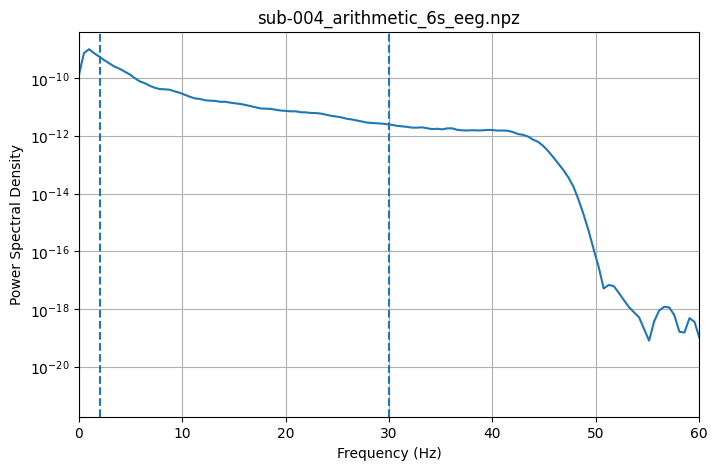

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import glob
import os

DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"

def plot_psd_subject(npz_path, max_freq=60):
    data = np.load(npz_path, allow_pickle=True)

    X = data["X"]           # (trials, channels, time)
    sfreq = float(data["sfreq"][0])

    # Flatten across trials for stability
    X_flat = X.reshape(-1, X.shape[-1])  # (trials*channels, time)

    # Compute PSD using Welch
    freqs, psd = welch(
        X_flat,
        fs=sfreq,
        nperseg=512,
        axis=-1
    )

    # Average across all signals
    psd_mean = psd.mean(axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.semilogy(freqs, psd_mean)
    plt.axvline(30, linestyle="--")  # cutoff marker
    plt.axvline(2, linestyle="--")
    plt.xlim(0, max_freq)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title(os.path.basename(npz_path))
    plt.grid(True)
    plt.show()


# ---- run on a few subjects ----
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))

for f in npz_files[:3]:  # plot first 3 subjects
    print("Plotting:", f)
    plot_psd_subject(f)

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-001_arithmetic_6s_eeg.npz


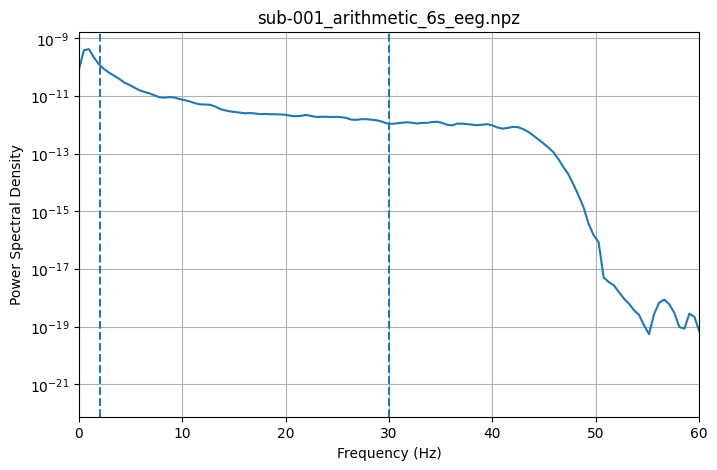

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-003_arithmetic_6s_eeg.npz


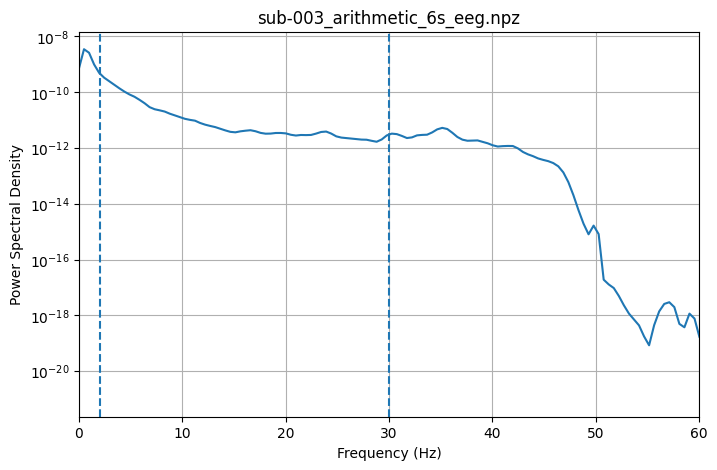

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-004_arithmetic_6s_eeg.npz


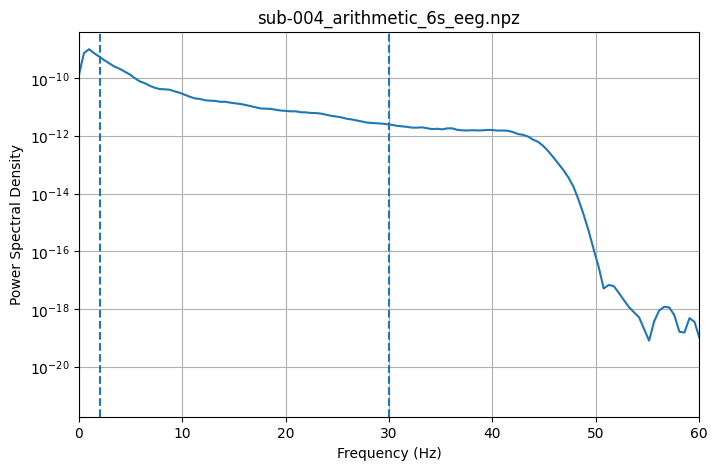

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import glob
import os

DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"

def plot_psd_subject(npz_path, max_freq=60):
    data = np.load(npz_path, allow_pickle=True)

    X = data["X"]           # (trials, channels, time)
    sfreq = float(data["sfreq"][0])

    # Flatten across trials for stability
    X_flat = X.reshape(-1, X.shape[-1])  # (trials*channels, time)

    # Compute PSD using Welch
    freqs, psd = welch(
        X_flat,
        fs=sfreq,
        nperseg=512,
        axis=-1
    )

    # Average across all signals
    psd_mean = psd.mean(axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.semilogy(freqs, psd_mean)
    plt.axvline(30, linestyle="--")  # cutoff marker
    plt.axvline(2, linestyle="--")
    plt.xlim(0, max_freq)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title(os.path.basename(npz_path))
    plt.grid(True)
    plt.show()


# ---- run on a few subjects ----
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))

for f in npz_files[:3]:  # plot first 3 subjects
    print("Plotting:", f)
    plot_psd_subject(f)

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-001_arithmetic_6s_eeg.npz


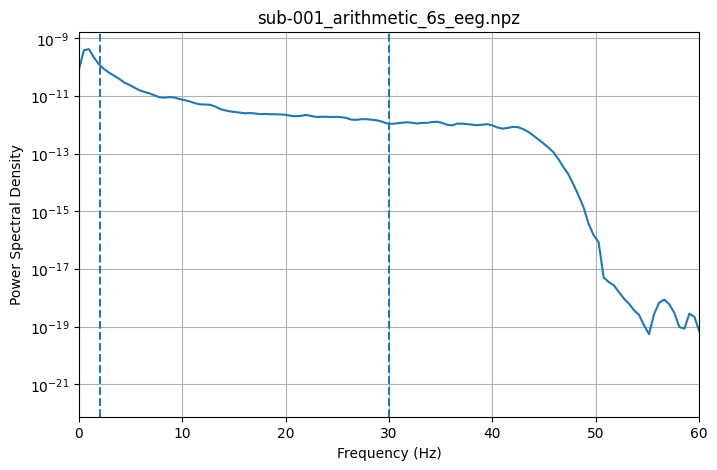

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-003_arithmetic_6s_eeg.npz


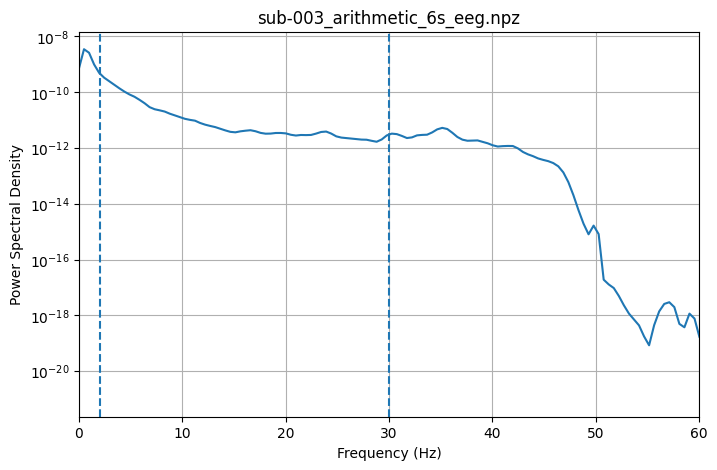

Plotting: /content/drive/MyDrive/openneuro_arithmetic_preprocessed/sub-004_arithmetic_6s_eeg.npz


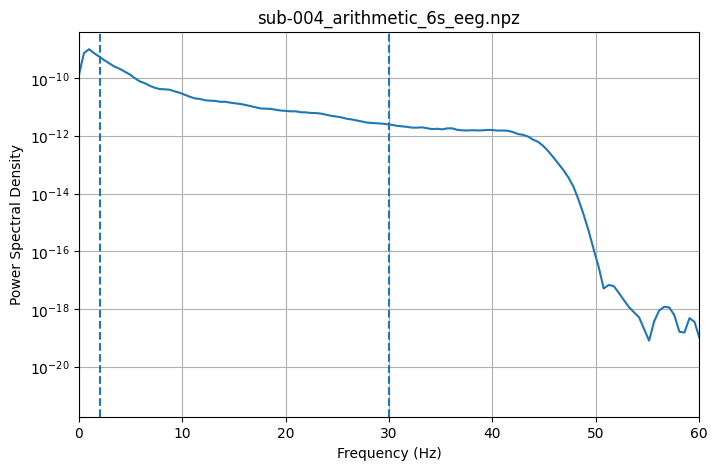

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import glob
import os

DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"

def plot_psd_subject(npz_path, max_freq=60):
    data = np.load(npz_path, allow_pickle=True)

    X = data["X"]           # (trials, channels, time)
    sfreq = float(data["sfreq"][0])

    # Flatten across trials for stability
    X_flat = X.reshape(-1, X.shape[-1])  # (trials*channels, time)

    # Compute PSD using Welch
    freqs, psd = welch(
        X_flat,
        fs=sfreq,
        nperseg=512,
        axis=-1
    )

    # Average across all signals
    psd_mean = psd.mean(axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.semilogy(freqs, psd_mean)
    plt.axvline(30, linestyle="--")  # cutoff marker
    plt.axvline(2, linestyle="--")
    plt.xlim(0, max_freq)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power Spectral Density")
    plt.title(os.path.basename(npz_path))
    plt.grid(True)
    plt.show()


# ---- run on a few subjects ----
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npz")))

for f in npz_files[:3]:  # plot first 3 subjects
    print("Plotting:", f)
    plot_psd_subject(f)

In [ ]:
"""
Arithmetic EEG — Contrastive Few-Shot LOSO Pipeline v4 + AdaBN + Mahalanobis
=============================================================================
Changes from original v4:
  - Kept architecture and training the same
  - Added AdaBN adaptation on held-out subject support set at test time
  - Replaced few-shot cosine classifier with Mahalanobis distance classifier
  - Added variance-based feature reweighting + covariance shrinkage
  - Few-shot eval now mirrors the stronger n-back evaluation style
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}
CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

EPOCHS             = 20
EPISODIC_START_EP  = 6
BATCH              = 256
LR                 = 3e-4
TEMP               = 0.1
LAMBDA_CON         = 0.5
LAMBDA_PROTO       = 0.2
FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 50
EMB_DIM            = 128
PROJ_DIM           = 64
BP_DIM             = 95    # 19 channels x 5 bands
TIME_DIM           = 32
BP_OUT_DIM         = 32

# Mahalanobis / adaptation params
SHRINK = 0.4

# ── BAND POWER ───────────────────────────────────────────────────────────────
def extract_bp(X, sfreq=SFREQ):
    out = []
    for trial in X:
        feats = []
        for ch in range(trial.shape[0]):
            freqs, psd = welch(trial[ch], fs=sfreq, nperseg=256, noverlap=128)
            for flo, fhi in BANDS.values():
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                feats.append(np.log(psd[idx].mean() + 1e-12))
        out.append(feats)
    return np.array(out, dtype=np.float32)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_bp, all_y, all_subj = [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d     = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep  = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_bp  = extract_bp(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(3)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_bp.append(X_bp)
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time   = np.concatenate(all_X_time, axis=0)
all_X_bp     = np.concatenate(all_X_bp,   axis=0)
all_y        = np.concatenate(all_y,      axis=0)

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: {{ {', '.join([f'{c}: {int((all_y == c).sum())}' for c in range(3)])} }}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_bp, y, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_bp   = torch.tensor(X_bp,   dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.subj   = torch.tensor(subj,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_bp[i], self.y[i], self.subj[i]

def make_weighted_loader(dataset, batch_size):
    y_np          = dataset.y.numpy()
    class_counts  = np.bincount(y_np, minlength=N_CLASSES).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = torch.tensor([class_weights[y] for y in y_np], dtype=torch.float)

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

# ── MODEL ────────────────────────────────────────────────────────────────────
class TimeBranch(nn.Module):
    """
    N-back style time branch adapted for 19 EEG channels x 1500 timepoints.
    Depthwise separable 1D conv -> channel attention -> attention pooling.
    Output: (B, 32)
    """
    def __init__(self, n_channels=N_CHANNELS, out_dim=TIME_DIM):
        super().__init__()

        self.depthwise = nn.Sequential(
            nn.Conv1d(n_channels, n_channels, kernel_size=7, padding=3, groups=n_channels),
            nn.BatchNorm1d(n_channels),
            nn.GELU(),

            nn.Conv1d(n_channels, n_channels, kernel_size=15, padding=7, groups=n_channels),
            nn.BatchNorm1d(n_channels),
            nn.GELU(),

            nn.Conv1d(n_channels, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(out_dim, out_dim // 4, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(out_dim // 4, out_dim, kernel_size=1),
            nn.Sigmoid(),
        )

        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.depthwise(x)               # (B, 32, T)
        scale = self.channel_attn(x)        # (B, 32, 1)
        x = x * scale
        weights = self.attn_pool(x)         # (B, 1, T)
        weights = F.softmax(weights, dim=-1)
        z = (x * weights).sum(dim=-1)       # (B, 32)
        return z

class BPBranch(nn.Module):
    def __init__(self, bp_dim=BP_DIM, out_dim=BP_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bp_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()
        self.time_branch = TimeBranch()
        self.bp_branch   = BPBranch()

        fusion_in = TIME_DIM + BP_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

    def forward(self, x_time, x_bp):
        z_time = self.time_branch(x_time)
        z_bp   = self.bp_branch(x_bp)
        e      = self.embed(torch.cat([z_time, z_bp], dim=1))
        return e, self.proj(e)

# ── LOSSES ───────────────────────────────────────────────────────────────────
def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto     = class_emb.mean(dim=0)
        loss     += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count    += 1

    return loss / max(count, 1)

def supcon_diff_subject_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B    = proj.size(0)

    sim  = (proj @ proj.t()) / temp
    sim  = sim - sim.max(dim=1, keepdim=True).values

    y    = y.view(-1, 1)
    subj = subj.view(-1, 1)

    same_y   = (y == y.t())
    diff_s   = (subj != subj.t())
    pos_mask = same_y & diff_s

    eye      = torch.eye(B, device=proj.device, dtype=torch.bool)
    pos_mask = pos_mask & (~eye)
    neg_mask = ~eye

    exp_sim    = torch.exp(sim) * neg_mask
    denom      = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob   = sim - torch.log(denom)
    pos_counts = pos_mask.sum(dim=1)

    loss_per_i = torch.zeros(B, device=proj.device)
    valid      = pos_counts > 0
    loss_per_i[valid] = (
        -(log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )

    if valid.any():
        return loss_per_i[valid].mean()
    return torch.tensor(0.0, device=proj.device)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp
    lmap   = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)
    return F.cross_entropy(logits, y_local)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []
    with torch.no_grad():
        for x_time, x_bp, y, _ in loader:
            e, _ = model(x_time.to(device), x_bp.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())
    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "bp_branch")):
    """
    Freeze all params, then put only selected BN layers into training mode
    so running mean/var update on support set (AdaBN).
    """
    for p in model.parameters():
        p.requires_grad = False

    allowed_modules = []
    for name, module in model.named_modules():
        if any(key in name for key in allow):
            allowed_modules.append((name, module))

    model.eval()

    for name, module in allowed_modules:
        for subname, submodule in module.named_modules():
            if isinstance(submodule, (nn.BatchNorm1d, nn.BatchNorm2d)):
                submodule.train()
                if hasattr(submodule, "weight") and submodule.weight is not None:
                    submodule.weight.requires_grad = False
                if hasattr(submodule, "bias") and submodule.bias is not None:
                    submodule.bias.requires_grad = False

# ── LOSO ─────────────────────────────────────────────────────────────────────
subjects_list   = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "="*70)
    print(f"FOLD {fold_i+1}/{len(subjects_list)} | TEST = {test_subj}")
    print("="*70)

    test_int   = subj_encoder[test_subj]
    test_mask  = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]
    X_bp_tr   = all_X_bp[train_mask]
    X_bp_te   = all_X_bp[test_mask]
    y_tr      = all_y[train_mask]
    y_te      = all_y[test_mask]
    subj_tr   = all_subj_int[train_mask]
    subj_te   = all_subj_int[test_mask]

    # train-only normalization
    time_mu   = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd   = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6
    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    bp_mu   = X_bp_tr.mean(axis=0, keepdims=True)
    bp_sd   = X_bp_tr.std(axis=0, keepdims=True) + 1e-6
    X_bp_tr = (X_bp_tr - bp_mu) / bp_sd
    X_bp_te = (X_bp_te - bp_mu) / bp_sd

    train_ds = EEGDataset(X_time_tr, X_bp_tr, y_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_bp_te, y_te, subj_te)

    train_loader = make_weighted_loader(train_ds, BATCH)
    test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

    model = ContrastiveModel().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_acc, best_state = -1.0, None
    train_subj_tensor    = train_ds.subj
    train_subjects_u     = torch.unique(train_subj_tensor).tolist()
    y_tr_t               = torch.tensor(y_tr, dtype=torch.long)

    # ── TRAIN ────────────────────────────────────────────────────────────────
    for ep in range(1, EPOCHS + 1):
        model.train()

        # regular contrastive training
        for x_time, x_bp, yb, sb in train_loader:
            x_time = x_time.to(device)
            x_bp   = x_bp.to(device)
            yb     = yb.to(device)
            sb     = sb.to(device)

            e, proj = model(x_time, x_bp)

            loss = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * supcon_diff_subject_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

        # episodic few-shot training
        if ep >= EPISODIC_START_EP:
            model.train()
            for _ in range(N_EPISODES):
                chosen_subj = random.choice(train_subjects_u)
                s_mask      = (train_subj_tensor == chosen_subj)
                s_idx       = s_mask.nonzero(as_tuple=True)[0]

                classes_s = torch.unique(y_tr_t[s_idx])
                if len(classes_s) < N_CLASSES:
                    continue

                sup_idx, qry_idx, skip = [], [], False
                for c in classes_s:
                    c_idx = s_idx[(y_tr_t[s_idx] == c)]
                    if len(c_idx) <= FEW_SHOT_PER_CLASS:
                        skip = True
                        break
                    perm = torch.randperm(len(c_idx))
                    sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])
                    qry_idx.append(c_idx[perm[FEW_SHOT_PER_CLASS:]])
                if skip:
                    continue

                sup_idx = torch.cat(sup_idx)
                qry_idx = torch.cat(qry_idx)

                xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
                xs_bp   = torch.tensor(X_bp_tr[sup_idx],   dtype=torch.float32).to(device)
                ys      = y_tr_t[sup_idx].to(device)

                xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
                xq_bp   = torch.tensor(X_bp_tr[qry_idx],   dtype=torch.float32).to(device)
                yq      = y_tr_t[qry_idx].to(device)

                e_sup, _ = model(xs_time, xs_bp)
                e_qry, _ = model(xq_time, xq_bp)

                classes_ep = torch.unique(ys)
                protos_ep  = torch.stack([e_sup[ys == c].mean(0) for c in classes_ep])

                logits = F.normalize(e_qry, dim=1) @ F.normalize(protos_ep, dim=1).T / 0.1
                lmap   = {int(c): i for i, c in enumerate(classes_ep)}
                yq_loc = torch.tensor([lmap[int(v)] for v in yq], device=device)

                l_ep = F.cross_entropy(logits, yq_loc)

                opt.zero_grad()
                l_ep.backward()
                opt.step()

        sched.step()

        # zero-shot eval (kept cosine; no support set exists here)
        model.eval()
        with torch.no_grad():
            e_tr, y_tr_full = extract_embeddings(model, DataLoader(train_ds, batch_size=128, shuffle=False), device)
            e_te, y_te_full = extract_embeddings(model, test_loader, device)

            classes = torch.unique(y_tr_full)
            protos  = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

            logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
            pred   = logits.argmax(dim=1)

            lmap  = {int(c): i for i, c in enumerate(classes)}
            y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

            acc = (pred == y_loc).float().mean().item()

        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(model.state_dict())

        pred_counts = torch.bincount(pred, minlength=N_CLASSES)
        print(
            f"  Ep {ep:02d} | zero-shot {acc:.4f} | best {best_acc:.4f} "
            f"| pred dist {pred_counts.tolist()}"
        )

    # ── FEW-SHOT EVAL: AdaBN + Mahalanobis ───────────────────────────────────
    model.load_state_dict(best_state)

    torch.manual_seed(1234 + fold_i)
    np.random.seed(1234 + fold_i)

    # 1) extract all test embeddings before adaptation only for support sampling
    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)
    all_e_pre, all_y_t = extract_embeddings(model, test_loader_full, device)

    # support sampling from held-out subject
    sup_idx = []
    for c in range(N_CLASSES):
        cidx = (all_y_t == c).nonzero(as_tuple=True)[0]
        if len(cidx) == 0:
            continue
        perm = torch.randperm(len(cidx))
        k = min(FEW_SHOT_PER_CLASS, len(cidx))
        sup_idx.append(cidx[perm[:k]])

    sup_idx  = torch.cat(sup_idx)
    sup_mask = torch.zeros(len(all_y_t), dtype=torch.bool)
    sup_mask[sup_idx] = True

    # 2) AdaBN adaptation using only support subset
    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(
        model,
        allow=("time_branch", "bp_branch")
    )

    with torch.no_grad():
        for xb_time, xb_bp, yb, sb in support_loader:
            _ = model(xb_time.to(device), xb_bp.to(device))

    # 3) re-extract embeddings after BN adaptation
    model.eval()
    all_e, all_y_t = extract_embeddings(model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)
    y_sup = all_y_t[sup_mask].to(device)
    y_qry = all_y_t[~sup_mask].to(device)

    # variance-based feature reweighting
    var     = e_sup.var(dim=0)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    # class prototypes
    protos = torch.stack([
        e_sup[y_sup == c].mean(0) for c in range(N_CLASSES)
    ])
    protos = F.normalize(protos, dim=1)

    # pooled covariance over residuals
    residuals = []
    for i, c in enumerate(range(N_CLASSES)):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            continue
        residuals.append(cls - protos[i])

    residuals = torch.cat(residuals, dim=0)

    D       = residuals.shape[1]
    cov     = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (1 - SHRINK) * cov + SHRINK * (avg_var * torch.eye(D, device=device))
    cov_inv    = torch.linalg.pinv(cov_shrink)

    # Mahalanobis distances
    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)           # (Nq, K, D)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred  = dists.argmin(dim=1)

    fs_acc         = (pred == y_qry).float().mean().item()
    pred_counts_fs = torch.bincount(pred, minlength=N_CLASSES)

    print(f"\n  >>> AdaBN + Mahalanobis few-shot acc ({test_subj}): {fs_acc:.4f} "
          f"| pred dist {pred_counts_fs.tolist()}")

    overall_results.append((
        test_subj,
        fs_acc,
        y_qry.cpu().numpy(),
        pred.cpu().numpy()
    ))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL LOSO SUMMARY")
print("="*70)

accs = [a for _, a, _, _ in overall_results]
for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1/N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])
print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")
for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: { 0: 290, 1: 273, 2: 410 }

FOLD 1/17 | TEST = sub-001
  Ep 01 | zero-shot 0.3158 | best 0.3158 | pred dist [56, 1, 0]
  Ep 02 | zero-shot 0.3158 | best 0.315

KeyboardInterrupt: 

In [ ]:
"""
Arithmetic EEG — Few-Shot-Only LOSO Pipeline
============================================
Goal:
  Optimize ONLY for few-shot adaptation on held-out subjects.

Key changes:
  - Best checkpoint selected by few-shot AdaBN + Mahalanobis accuracy
  - Episodic training starts from epoch 1
  - Episodic loss weighted explicitly
  - Zero-shot accuracy is diagnostic only (not used for model selection)
  - Architecture and feature extraction otherwise unchanged
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}
CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

EPOCHS             = 30
BATCH              = 256
LR                 = 3e-4
TEMP               = 0.1

# train loss weights
LAMBDA_CON         = 0.2
LAMBDA_PROTO       = 0.3
LAMBDA_EPISODIC    = 2.0

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 150

EMB_DIM            = 128
PROJ_DIM           = 64
BP_DIM             = 95
TIME_DIM           = 32
BP_OUT_DIM         = 32

# Mahalanobis / adaptation
SHRINK             = 0.4
ADABN_PASSES       = 1   # number of passes over support set for BN stat adaptation

# ── BAND POWER ───────────────────────────────────────────────────────────────
def extract_bp(X, sfreq=SFREQ):
    out = []
    for trial in X:
        feats = []
        for ch in range(trial.shape[0]):
            freqs, psd = welch(trial[ch], fs=sfreq, nperseg=256, noverlap=128)
            for flo, fhi in BANDS.values():
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                feats.append(np.log(psd[idx].mean() + 1e-12))
        out.append(feats)
    return np.array(out, dtype=np.float32)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_bp, all_y, all_subj = [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d     = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep  = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_bp  = extract_bp(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(3)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_bp.append(X_bp)
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_bp   = np.concatenate(all_X_bp,   axis=0)
all_y      = np.concatenate(all_y,      axis=0)

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(3)} }")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_bp, y, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_bp   = torch.tensor(X_bp,   dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.subj   = torch.tensor(subj,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_bp[i], self.y[i], self.subj[i]

def make_weighted_loader(dataset, batch_size):
    y_np          = dataset.y.numpy()
    class_counts  = np.bincount(y_np, minlength=N_CLASSES).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = torch.tensor([class_weights[y] for y in y_np], dtype=torch.float)

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=False)

# ── MODEL ─────────────────────────────────────────────────────────────────────
class TimeBranch(nn.Module):
    """
    N-back style time branch adapted for 19 EEG channels x 1500 timepoints.
    Depthwise separable 1D conv -> channel attention -> attention pooling.
    Output: (B, 32)
    """
    def __init__(self, n_channels=N_CHANNELS, out_dim=TIME_DIM):
        super().__init__()

        self.depthwise = nn.Sequential(
            nn.Conv1d(n_channels, n_channels, kernel_size=7, padding=3, groups=n_channels),
            nn.BatchNorm1d(n_channels),
            nn.GELU(),

            nn.Conv1d(n_channels, n_channels, kernel_size=15, padding=7, groups=n_channels),
            nn.BatchNorm1d(n_channels),
            nn.GELU(),

            nn.Conv1d(n_channels, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(out_dim, out_dim // 4, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(out_dim // 4, out_dim, kernel_size=1),
            nn.Sigmoid(),
        )

        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.depthwise(x)               # (B, 32, 1500)
        scale = self.channel_attn(x)        # (B, 32, 1)
        x = x * scale
        weights = self.attn_pool(x)         # (B, 1, 1500)
        weights = F.softmax(weights, dim=-1)
        z = (x * weights).sum(dim=-1)       # (B, 32)
        return z

class BPBranch(nn.Module):
    def __init__(self, bp_dim=BP_DIM, out_dim=BP_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bp_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()
        self.time_branch = TimeBranch()
        self.bp_branch   = BPBranch()

        fusion_in = TIME_DIM + BP_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(128, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

    def forward(self, x_time, x_bp):
        z_time = self.time_branch(x_time)
        z_bp   = self.bp_branch(x_bp)
        e      = self.embed(torch.cat([z_time, z_bp], dim=1))
        return e, self.proj(e)

# ── LOSSES ───────────────────────────────────────────────────────────────────
def prototype_loss(emb, y):
    """Within-class compactness."""
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto     = class_emb.mean(dim=0)
        loss     += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count    += 1

    return loss / max(count, 1)

def supcon_diff_subject_loss(proj, y, subj, temp=TEMP):
    """Positives = same class, different subject."""
    proj = F.normalize(proj, dim=1)
    B    = proj.size(0)

    sim  = (proj @ proj.t()) / temp
    sim  = sim - sim.max(dim=1, keepdim=True).values

    y    = y.view(-1, 1)
    subj = subj.view(-1, 1)

    same_y   = (y == y.t())
    diff_s   = (subj != subj.t())
    pos_mask = same_y & diff_s

    eye      = torch.eye(B, device=proj.device, dtype=torch.bool)
    pos_mask = pos_mask & (~eye)
    neg_mask = ~eye

    exp_sim    = torch.exp(sim) * neg_mask
    denom      = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob   = sim - torch.log(denom)
    pos_counts = pos_mask.sum(dim=1)

    loss_per_i = torch.zeros(B, device=proj.device)
    valid      = pos_counts > 0
    loss_per_i[valid] = (
        -(log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )

    return loss_per_i[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

def prototype_ce_loss(e, labels, temp=0.1):
    """CE against in-batch prototypes."""
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos  = torch.stack([e[labels == c].mean(0) for c in classes])
    logits  = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp
    lmap    = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)
    return F.cross_entropy(logits, y_local)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []
    with torch.no_grad():
        for x_time, x_bp, y, _ in loader:
            e, _ = model(x_time.to(device), x_bp.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())
    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "bp_branch")):
    """
    Freeze all params, put only selected BN layers into train mode so
    running mean/var update on support set (AdaBN).
    """
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []
    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]
        if len(cidx) < shots_per_class:
            return None
        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])
    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    """
    Few-shot evaluation on held-out subject:
      1) sample support set
      2) AdaBN on support
      3) extract embeddings
      4) variance reweighting
      5) pooled-covariance Mahalanobis
    Returns:
      fs_acc, y_query_cpu, pred_cpu, pred_counts_list
    """
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    # Pre-adaptation embeddings only used to choose support indices consistently
    all_e_pre, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)
    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    # AdaBN on support subset
    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "bp_branch"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_bp, yb, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_bp.to(device))

    eval_model.eval()

    # Re-extract embeddings after adaptation
    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)
    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    # variance-based feature reweighting
    var     = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    # prototypes
    protos = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))
    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    # pooled covariance over residuals
    residuals = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])
    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]
    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D
    cov_shrink = (1 - SHRINK) * cov + SHRINK * (avg_var * torch.eye(D, device=device))
    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)   # (Nq, K, D)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred  = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    """
    Diagnostic only. Not used for model selection.
    """
    model.eval()
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos  = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred   = logits.argmax(dim=1)

        lmap  = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO ─────────────────────────────────────────────────────────────────────
subjects_list   = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "="*70)
    print(f"FOLD {fold_i+1}/{len(subjects_list)} | TEST = {test_subj}")
    print("="*70)

    test_int   = subj_encoder[test_subj]
    test_mask  = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]
    X_bp_tr   = all_X_bp[train_mask]
    X_bp_te   = all_X_bp[test_mask]
    y_tr      = all_y[train_mask]
    y_te      = all_y[test_mask]
    subj_tr   = all_subj_int[train_mask]
    subj_te   = all_subj_int[test_mask]

    # train-only normalization
    time_mu   = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd   = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6
    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    bp_mu   = X_bp_tr.mean(axis=0, keepdims=True)
    bp_sd   = X_bp_tr.std(axis=0, keepdims=True) + 1e-6
    X_bp_tr = (X_bp_tr - bp_mu) / bp_sd
    X_bp_te = (X_bp_te - bp_mu) / bp_sd

    train_ds = EEGDataset(X_time_tr, X_bp_tr, y_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_bp_te, y_te, subj_te)

    train_loader = make_weighted_loader(train_ds, BATCH)

    model = ContrastiveModel().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc   = -1.0
    best_state    = None
    best_epoch    = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u  = torch.unique(train_subj_tensor).tolist()
    y_tr_t            = torch.tensor(y_tr, dtype=torch.long)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps      = 0

        # ── regular batch training ────────────────────────────────────────────
        for x_time, x_bp, yb, sb in train_loader:
            x_time = x_time.to(device)
            x_bp   = x_bp.to(device)
            yb     = yb.to(device)
            sb     = sb.to(device)

            e, proj = model(x_time, x_bp)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * supcon_diff_subject_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training from epoch 1 ───────────────────────────
        running_ep_loss = 0.0
        n_ep_steps      = 0

        model.train()
        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)
            s_mask      = (train_subj_tensor == chosen_subj)
            s_idx       = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])
            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]
                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break
                perm = torch.randperm(len(c_idx))
                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])
                qry_idx.append(c_idx[perm[FEW_SHOT_PER_CLASS:]])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_bp   = torch.tensor(X_bp_tr[sup_idx],   dtype=torch.float32).to(device)
            ys      = y_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_bp   = torch.tensor(X_bp_tr[qry_idx],   dtype=torch.float32).to(device)
            yq      = y_tr_t[qry_idx].to(device)

            e_sup, _ = model(xs_time, xs_bp)
            e_qry, _ = model(xq_time, xq_bp)

            protos_ep = torch.stack([e_sup[ys == c].mean(0) for c in range(N_CLASSES)])

            logits_ep = F.normalize(e_qry, dim=1) @ F.normalize(protos_ep, dim=1).T / 0.1
            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            # support/query compactness regularization
            loss_ep_proto = prototype_loss(torch.cat([e_sup, e_qry], dim=0),
                                           torch.cat([ys, yq], dim=0))

            loss_episode = LAMBDA_EPISODIC * (loss_ep_ce + 0.25 * loss_ep_proto)

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL (used for checkpointing) ───────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL (diagnostic only) ─────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state  = copy.deepcopy(model.state_dict())
            best_epoch  = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss    = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")
    model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL FEW-SHOT-ONLY LOSO SUMMARY")
print("="*70)

accs = [a for _, a, _, _ in overall_results]
for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1/N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])
print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")
for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 16.3951 | ep 12.1252 | few-shot 0.4048 | best-fs 0.4048 | zero-shot 0.2632 | fs pred [15,

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline
================================================
Goal:
  Improve FEW-SHOT workload classification through:
    - stronger temporal encoder
    - richer neural features
    - workload-aware losses
    - episodic few-shot training
    - AdaBN + Mahalanobis evaluation / checkpointing

Main upgrades:
  1) Better encoder:
      - spatial mixing
      - multiscale temporal branches
      - residual temporal blocks
      - squeeze-excitation style channel attention
      - attention pooling
  2) Better handcrafted neural features:
      - log band power
      - differential entropy
      - Hjorth parameters
      - spectral entropy
      - spectral centroid
      - mean absolute value
      - zero crossing rate
      - global band-ratio summaries
  3) Better losses:
      - prototype CE
      - distance-aware contrastive loss (ordinal-aware)
      - prototype compactness
      - prototype ordering loss
  4) Same strong evaluation:
      - few-shot AdaBN + Mahalanobis for checkpoint selection
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}
CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS             = 15
BATCH              = 256
LR                 = 3e-4
TEMP               = 0.1

# loss weights
LAMBDA_CON         = 0.35
LAMBDA_PROTO       = 0.40
LAMBDA_ORDER       = 0.20
LAMBDA_EPISODIC    = 1.25

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 120
EP_QUERY_CAP       = 12   # max query samples per class per episode

# model dims
EMB_DIM            = 192
PROJ_DIM           = 64
TIME_DIM           = 128
FEAT_OUT_DIM       = 64
SPATIAL_DIM        = 32

# eval
SHRINK             = 0.4
ADABN_PASSES       = 3

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Per-trial features:
      - log band power: 19 * 5 = 95
      - differential entropy: 19 * 5 = 95
      - Hjorth params: 19 * 3 = 57
      - spectral entropy: 19
      - spectral centroid: 19
      - MAV: 19
      - ZCR: 19
      - global band ratios / summaries: 8
    Total = 312
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats     = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats    = []
        zcr_feats    = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        # global summaries
        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_subj = [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d     = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep  = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin  = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(3)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(3)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.subj   = torch.tensor(subj,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.subj[i]

def make_weighted_loader(dataset, batch_size):
    y_np          = dataset.y.numpy()
    class_counts  = np.bincount(y_np, minlength=N_CLASSES).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = torch.tensor([class_weights[y] for y in y_np], dtype=torch.float)

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=False)

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    """
    Stronger workload encoder:
      - spatial mixing
      - multiscale temporal branches
      - residual temporal blocks
      - SE attention
      - attention pooling
    """
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)
        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()
        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)
        e      = self.embed(torch.cat([z_time, z_feat], dim=1))
        return e, self.proj(e)

# ── LOSSES ───────────────────────────────────────────────────────────────────
def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto     = class_emb.mean(dim=0)
        loss     += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count    += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos  = torch.stack([e[labels == c].mean(0) for c in classes])
    logits  = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp
    lmap    = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)
    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    """
    Workload-aware contrastive loss:
      same class -> pull strongly
      adjacent class -> weak push
      far class -> strong push
    """
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y    = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()
    same_y   = (label_dist == 0)
    adj_y    = (label_dist == 1)
    far_y    = (label_dist >= 2)
    diff_s   = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim  = torch.exp(sim) * neg_mask
    denom    = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    # positive pull
    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0
    pull[valid] = -((log_prob * pos_mask.float()).sum(dim=1)[valid] / pos_counts[valid].float())
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    # soft negative / strong negative margins
    sim_raw = proj @ proj.t()
    adj_pen = F.relu(sim_raw[adj_mask] - 0.30).mean() if adj_mask.any() else torch.tensor(0.0, device=proj.device)
    far_pen = F.relu(sim_raw[far_mask] - 0.10).mean() if far_mask.any() else torch.tensor(0.0, device=proj.device)

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    """
    Encourage Low-Med-High ordinal geometry:
      d(L,M) and d(M,H) should both be smaller than d(L,H)
    """
    classes = torch.unique(y)
    if len(classes) < 3:
        return torch.tensor(0.0, device=emb.device)

    needed = [0, 1, 2]
    if not all([(y == c).sum() > 0 for c in needed]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    loss = F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)
    return loss

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []
    with torch.no_grad():
        for x_time, x_feat, y, _ in loader:
            e, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())
    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []
    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]
        if len(cidx) < shots_per_class:
            return None
        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])
    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)
    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()
    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)
    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var     = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))
    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])
    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]
    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D
    cov_shrink = (1 - SHRINK) * cov + SHRINK * (avg_var * torch.eye(D, device=device))
    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred  = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos  = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred   = logits.argmax(dim=1)

        lmap  = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO ─────────────────────────────────────────────────────────────────────
subjects_list   = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "="*70)
    print(f"FOLD {fold_i+1}/{len(subjects_list)} | TEST = {test_subj}")
    print("="*70)

    test_int   = subj_encoder[test_subj]
    test_mask  = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]
    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]
    y_tr      = all_y[train_mask]
    y_te      = all_y[test_mask]
    subj_tr   = all_subj_int[train_mask]
    subj_te   = all_subj_int[test_mask]

    # train-only normalization
    time_mu   = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd   = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6
    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu   = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd   = X_feat_tr.std(axis=0, keepdims=True) + 1e-6
    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, subj_te)

    train_loader = make_weighted_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc   = -1.0
    best_state    = None
    best_epoch    = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u  = torch.unique(train_subj_tensor).tolist()
    y_tr_t            = torch.tensor(y_tr, dtype=torch.long)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps      = 0

        # ── regular batch training ────────────────────────────────────────────
        for x_time, x_feat, yb, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb     = yb.to(device)
            sb     = sb.to(device)

            e, proj = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps      = 0

        model.train()
        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)
            s_mask      = (train_subj_tensor == chosen_subj)
            s_idx       = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])
            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]
                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))
                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys      = y_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq      = y_tr_t[qry_idx].to(device)

            e_sup, _ = model(xs_time, xs_feat)
            e_qry, _ = model(xq_time, xq_feat)

            protos_ep = torch.stack([e_sup[ys == c].mean(0) for c in range(N_CLASSES)])

            logits_ep = F.normalize(e_qry, dim=1) @ F.normalize(protos_ep, dim=1).T / 0.1
            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            loss_ep_proto = prototype_loss(torch.cat([e_sup, e_qry], dim=0),
                                           torch.cat([ys, yq], dim=0))
            loss_ep_order = proto_order_loss(torch.cat([e_sup, e_qry], dim=0),
                                             torch.cat([ys, yq], dim=0))

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL (checkpointing) ────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL (diagnostic only) ─────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state  = copy.deepcopy(model.state_dict())
            best_epoch  = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss    = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")
    model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("="*70)

accs = [a for _, a, _, _ in overall_results]
for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1/N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])
print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")
for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.7746 | ep 8.2514 | few-shot 0.3571 | best-fs 0.3571 | zero-shot 0.263

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline
================================================
Goal:
  Improve FEW-SHOT workload classification through:
    - stronger temporal encoder
    - richer neural features
    - workload-aware losses
    - episodic few-shot training
    - AdaBN + Mahalanobis evaluation / checkpointing

Main upgrades:
  1) Better encoder:
      - spatial mixing
      - multiscale temporal branches
      - residual temporal blocks
      - squeeze-excitation style channel attention
      - attention pooling
  2) Better handcrafted neural features:
      - log band power
      - differential entropy
      - Hjorth parameters
      - spectral entropy
      - spectral centroid
      - mean absolute value
      - zero crossing rate
      - global band-ratio summaries
  3) Better losses:
      - prototype CE
      - distance-aware contrastive loss (ordinal-aware)
      - prototype compactness
      - prototype ordering loss
  4) Same strong evaluation:
      - few-shot AdaBN + Mahalanobis for checkpoint selection
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}
CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS             = 15
BATCH              = 256
LR                 = 3e-4
TEMP               = 0.1

# loss weights
LAMBDA_CON         = 0.35
LAMBDA_PROTO       = 0.40
LAMBDA_ORDER       = 0.20
LAMBDA_EPISODIC    = 1.25

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 120
EP_QUERY_CAP       = 12   # max query samples per class per episode

# model dims
EMB_DIM            = 192
PROJ_DIM           = 64
TIME_DIM           = 128
FEAT_OUT_DIM       = 64
SPATIAL_DIM        = 32

# eval
SHRINK             = 0.4
ADABN_PASSES       = 3


class SubjectClassBalancedBatchSampler:
    """
    Subject-balanced + class-aware batch sampler.

    Goal:
      Each regular training batch should contain:
        - multiple subjects
        - all workload classes when possible
        - same-class examples across different subjects

    This directly helps distance_aware_contrastive_loss because that loss needs:
        same_y & diff_s
    positives inside the same batch.
    """
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))

        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []

        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            # Fill remaining slots while preserving class + subject diversity.
            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]

                if len(pool) == 0:
                    continue

                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )






# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Per-trial features:
      - log band power: 19 * 5 = 95
      - differential entropy: 19 * 5 = 95
      - Hjorth params: 19 * 3 = 57
      - spectral entropy: 19
      - spectral centroid: 19
      - MAV: 19
      - ZCR: 19
      - global band ratios / summaries: 8
    Total = 312
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats     = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats    = []
        zcr_feats    = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        # global summaries
        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_subj = [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d     = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep  = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin  = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(3)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(3)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.subj   = torch.tensor(subj,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.subj[i]

def make_weighted_loader(dataset, batch_size):
    y_np          = dataset.y.numpy()
    class_counts  = np.bincount(y_np, minlength=N_CLASSES).astype(np.float32)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = torch.tensor([class_weights[y] for y in y_np], dtype=torch.float)

    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=False)

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    """
    Stronger workload encoder:
      - spatial mixing
      - multiscale temporal branches
      - residual temporal blocks
      - SE attention
      - attention pooling
    """
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)
        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()
        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)
        e      = self.embed(torch.cat([z_time, z_feat], dim=1))
        return e, self.proj(e)

# ── LOSSES ───────────────────────────────────────────────────────────────────
def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto     = class_emb.mean(dim=0)
        loss     += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count    += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos  = torch.stack([e[labels == c].mean(0) for c in classes])
    logits  = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp
    lmap    = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)
    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    """
    Workload-aware contrastive loss:
      same class -> pull strongly
      adjacent class -> weak push
      far class -> strong push
    """
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y    = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()
    same_y   = (label_dist == 0)
    adj_y    = (label_dist == 1)
    far_y    = (label_dist >= 2)
    diff_s   = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim  = torch.exp(sim) * neg_mask
    denom    = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    # positive pull
    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0
    pull[valid] = -((log_prob * pos_mask.float()).sum(dim=1)[valid] / pos_counts[valid].float())
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    # soft negative / strong negative margins
    sim_raw = proj @ proj.t()
    adj_pen = F.relu(sim_raw[adj_mask] - 0.30).mean() if adj_mask.any() else torch.tensor(0.0, device=proj.device)
    far_pen = F.relu(sim_raw[far_mask] - 0.10).mean() if far_mask.any() else torch.tensor(0.0, device=proj.device)

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    """
    Encourage Low-Med-High ordinal geometry:
      d(L,M) and d(M,H) should both be smaller than d(L,H)
    """
    classes = torch.unique(y)
    if len(classes) < 3:
        return torch.tensor(0.0, device=emb.device)

    needed = [0, 1, 2]
    if not all([(y == c).sum() > 0 for c in needed]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    loss = F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)
    return loss

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []
    with torch.no_grad():
        for x_time, x_feat, y, _ in loader:
            e, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())
    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []
    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]
        if len(cidx) < shots_per_class:
            return None
        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])
    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)
    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()
    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)
    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var     = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))
    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])
    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]
    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D
    cov_shrink = (1 - SHRINK) * cov + SHRINK * (avg_var * torch.eye(D, device=device))
    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred  = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos  = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred   = logits.argmax(dim=1)

        lmap  = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO ─────────────────────────────────────────────────────────────────────
subjects_list   = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "="*70)
    print(f"FOLD {fold_i+1}/{len(subjects_list)} | TEST = {test_subj}")
    print("="*70)

    test_int   = subj_encoder[test_subj]
    test_mask  = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]
    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]
    y_tr      = all_y[train_mask]
    y_te      = all_y[test_mask]
    subj_tr   = all_subj_int[train_mask]
    subj_te   = all_subj_int[test_mask]

    # train-only normalization
    time_mu   = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd   = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6
    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu   = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd   = X_feat_tr.std(axis=0, keepdims=True) + 1e-6
    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc   = -1.0
    best_state    = None
    best_epoch    = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u  = torch.unique(train_subj_tensor).tolist()
    y_tr_t            = torch.tensor(y_tr, dtype=torch.long)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps      = 0

        # ── regular batch training ────────────────────────────────────────────
        for x_time, x_feat, yb, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb     = yb.to(device)
            sb     = sb.to(device)

            e, proj = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps      = 0

        model.train()
        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)
            s_mask      = (train_subj_tensor == chosen_subj)
            s_idx       = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])
            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]
                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))
                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys      = y_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq      = y_tr_t[qry_idx].to(device)

            e_sup, _ = model(xs_time, xs_feat)
            e_qry, _ = model(xq_time, xq_feat)

            protos_ep = torch.stack([e_sup[ys == c].mean(0) for c in range(N_CLASSES)])

            logits_ep = F.normalize(e_qry, dim=1) @ F.normalize(protos_ep, dim=1).T / 0.1
            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            loss_ep_proto = prototype_loss(torch.cat([e_sup, e_qry], dim=0),
                                           torch.cat([ys, yq], dim=0))
            loss_ep_order = proto_order_loss(torch.cat([e_sup, e_qry], dim=0),
                                             torch.cat([ys, yq], dim=0))

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL (checkpointing) ────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL (diagnostic only) ─────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state  = copy.deepcopy(model.state_dict())
            best_epoch  = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss    = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")
    model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("="*70)

accs = [a for _, a, _, _ in overall_results]
for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1/N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])
print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")
for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.7530 | ep 7.6021 | few-shot 0.4762 | best-fs 0.4762 | zero-shot 0.228

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline + Raw 7-Level Auxiliary Ordinal Loss
====================================================================================
Main task:
  3-bin workload classification:
    0,1 -> Low
    2,3 -> Med
    4,5,6 -> High

Auxiliary task:
  Predict original raw 7-level label as an ordinal scalar during training only.
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.20
LAMBDA_EPISODIC = 1.25

# new auxiliary raw-7 ordinal loss
LAMBDA_RAW7 = 0.15
RAW7_SCALE  = 6.0

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) == 0:
                    continue
                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Actual feature dim:
      log band power:       19 * 5 = 95
      differential entropy: 19 * 5 = 95
      Hjorth params:        19 * 3 = 57
      spectral entropy:     19
      spectral centroid:    19
      MAV:                  19
      ZCR:                  19
      global summaries:     8
    Total = 331
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        return e, proj, raw7_logit

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)

    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for x_time, x_feat, yb, y7b, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb = yb.to(device)
            y7b = y7b.to(device)
            sb = sb.to(device)

            e, proj, raw7_logit = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            e_sup, _, raw7_sup = model(xs_time, xs_feat)
            e_qry, _, raw7_qry = model(xq_time, xq_feat)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)

            loss_ep_raw7 = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s, y7q], dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.6773 | ep 7.7474 | few-shot 0.3571 | best-fs 0.3571 | zero-shot 0.280

In [ ]:
#INCREASING FEW SHOT TO 7

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline + Raw 7-Level Auxiliary Ordinal Loss
====================================================================================
Main task:
  3-bin workload classification:
    0,1 -> Low
    2,3 -> Med
    4,5,6 -> High

Auxiliary task:
  Predict original raw 7-level label as an ordinal scalar during training only.
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.20
LAMBDA_EPISODIC = 1.25

# new auxiliary raw-7 ordinal loss
LAMBDA_RAW7 = 0.15
RAW7_SCALE  = 6.0

FEW_SHOT_PER_CLASS = 7
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) == 0:
                    continue
                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Actual feature dim:
      log band power:       19 * 5 = 95
      differential entropy: 19 * 5 = 95
      Hjorth params:        19 * 3 = 57
      spectral entropy:     19
      spectral centroid:    19
      MAV:                  19
      ZCR:                  19
      global summaries:     8
    Total = 331
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        return e, proj, raw7_logit

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)

    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for x_time, x_feat, yb, y7b, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb = yb.to(device)
            y7b = y7b.to(device)
            sb = sb.to(device)

            e, proj, raw7_logit = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            e_sup, _, raw7_sup = model(xs_time, xs_feat)
            e_qry, _, raw7_qry = model(xq_time, xq_feat)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)

            loss_ep_raw7 = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s, y7q], dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.6773 | ep 7.4347 | few-shot 0.3889 | best-fs 0.3889 | zero-shot 0.263

In [ ]:
#THIS WAS US CHANGING OBJECTIVE COMPLETELY TO 7 CLASS REGRESSION, AND BINNING IN THE END AFTER

In [ ]:
"""
Arithmetic EEG — LOSO Raw-7 Ordinal/Regression Pipeline
=======================================================

Main task:
  Predict raw workload label 0–6 directly.

Training losses:
  1) Ordinal threshold loss:
       y > 0, y > 1, ..., y > 5
  2) Scalar SmoothL1 regression:
       y / 6

Evaluation:
  - MAE on raw 0–6
  - Pearson correlation
  - Spearman correlation
  - rounded raw-7 accuracy
  - recovered 3-bin accuracy:
        0,1 -> Low
        2,3 -> Med
        4,5,6 -> High
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from scipy.signal import welch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ = 250.0
EXCLUDE = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}

BIN_MAP = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES = 3
N_RAW_LEVELS = 7
N_THRESHOLDS = 6

N_CHANNELS = 19
N_TIMES = 1500

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH = 256
LR = 3e-4

# loss weights
LAMBDA_ORDINAL = 1.00
LAMBDA_REG     = 0.50
RAW7_SCALE     = 6.0

# few-shot/adaptation eval
FEW_SHOT_PER_CLASS = 7
ADABN_PASSES = 3

# model dims
EMB_DIM      = 192
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    """
    Uses 3-bin y only for balanced batch construction.
    Model still trains on raw y7.
    """
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y_bin.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]

                if len(pool) == 0:
                    continue

                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12

                band_means.append(band_power)
                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y_bin, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y7 = np.array([int(l) for l in y_raw], dtype=np.float32)
    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)

    X_feat = extract_features(X_raw)

    counts_raw = {c: int((y7 == c).sum()) for c in range(N_RAW_LEVELS)}
    counts_bin = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}

    print(f"  {sub_id}: {len(X_raw)} trials | bin {counts_bin} | raw {counts_raw}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y_bin.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y7), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y_bin  = np.concatenate(all_y_bin, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y7)} trials | subjects: {len(subj_encoder)}")
print(f"Raw label dist: { {c: int((all_y7 == c).sum()) for c in range(N_RAW_LEVELS)} }")
print(f"3-bin dist: { {c: int((all_y_bin == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y_bin, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y_bin  = torch.tensor(y_bin, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y7)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y_bin[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()

        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(
                channels,
                channels,
                kernel_size=kernel_size,
                padding=pad,
                dilation=dilation,
                groups=channels,
            ),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 8)

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=2, dropout=0.10),
        )

        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )

        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class OrdinalRegressionModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.ordinal_head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(128, N_THRESHOLDS),
        )

        self.reg_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))

        ordinal_logits = self.ordinal_head(e)
        reg_logit = self.reg_head(e).squeeze(1)

        return e, ordinal_logits, reg_logit

# ── LOSSES / PREDICTION HELPERS ──────────────────────────────────────────────
def make_ordinal_targets(y7):
    """
    y = 0 -> [0,0,0,0,0,0]
    y = 1 -> [1,0,0,0,0,0]
    y = 6 -> [1,1,1,1,1,1]
    """
    thresholds = torch.arange(N_THRESHOLDS, device=y7.device).float()
    return (y7.unsqueeze(1) > thresholds.unsqueeze(0)).float()

def ordinal_threshold_loss(ordinal_logits, y7):
    targets = make_ordinal_targets(y7)
    return F.binary_cross_entropy_with_logits(ordinal_logits, targets)

def scalar_regression_loss(reg_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(reg_logit)
    return F.smooth_l1_loss(pred, target)

def predict_raw7_from_outputs(ordinal_logits, reg_logit, alpha=0.70):
    """
    ordinal estimate = sum P(y > k), range 0–6
    scalar estimate  = sigmoid(reg_logit) * 6
    final prediction = weighted blend
    """
    ordinal_probs = torch.sigmoid(ordinal_logits)
    ordinal_est = ordinal_probs.sum(dim=1)

    scalar_est = torch.sigmoid(reg_logit) * RAW7_SCALE

    pred = alpha * ordinal_est + (1.0 - alpha) * scalar_est
    return pred

def raw7_to_bin_np(y):
    y = np.asarray(y)
    out = np.zeros_like(y, dtype=np.int64)
    out[(y >= 2) & (y <= 3)] = 1
    out[y >= 4] = 2
    return out

def rounded_raw7_np(pred):
    return np.clip(np.rint(pred), 0, 6).astype(np.int64)

# ── EVAL HELPERS ─────────────────────────────────────────────────────────────
def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()

                if module.weight is not None:
                    module.weight.requires_grad = False

                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(y_bin, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (y_bin == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def predict_dataset(model, loader, device):
    model.eval()

    pred_all = []
    y7_all = []
    ybin_all = []

    with torch.no_grad():
        for x_time, x_feat, y_bin, y7, subj in loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)

            _, ord_logits, reg_logit = model(x_time, x_feat)
            pred_y7 = predict_raw7_from_outputs(ord_logits, reg_logit)

            pred_all.append(pred_y7.cpu())
            y7_all.append(y7.cpu())
            ybin_all.append(y_bin.cpu())

    return (
        torch.cat(pred_all).numpy(),
        torch.cat(y7_all).numpy(),
        torch.cat(ybin_all).numpy(),
    )

def evaluate_regression_fewshot_adabn(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, _, all_ybin = predict_dataset(eval_model, test_loader_full, device)
    all_ybin_t = torch.tensor(all_ybin, dtype=torch.long)

    sup_idx = sample_fewshot_support_indices(
        all_ybin_t,
        FEW_SHOT_PER_CLASS,
        seed=fold_seed
    )

    if sup_idx is None:
        return None

    sup_mask = np.zeros(len(all_ybin), dtype=bool)
    sup_mask[sup_idx.numpy()] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb_bin, yb7, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    pred_y7, true_y7, true_ybin = predict_dataset(eval_model, test_loader_full, device)

    pred_q = pred_y7[~sup_mask]
    true_q = true_y7[~sup_mask]
    true_bin_q = true_ybin[~sup_mask]

    pred_raw_round = rounded_raw7_np(pred_q)
    pred_bin_q = raw7_to_bin_np(pred_raw_round)

    mae = float(np.mean(np.abs(pred_q - true_q)))
    raw7_acc = float(np.mean(pred_raw_round == true_q.astype(np.int64)))
    bin_acc = float(np.mean(pred_bin_q == true_bin_q.astype(np.int64)))

    if len(np.unique(pred_q)) > 1 and len(np.unique(true_q)) > 1:
        pear = float(pearsonr(pred_q, true_q)[0])
        spear = float(spearmanr(pred_q, true_q)[0])
    else:
        pear = np.nan
        spear = np.nan

    pred_counts_bin = np.bincount(pred_bin_q, minlength=N_CLASSES).tolist()

    return {
        "mae": mae,
        "pearson": pear,
        "spearman": spear,
        "raw7_acc": raw7_acc,
        "bin_acc": bin_acc,
        "true_y7": true_q.astype(np.float32),
        "pred_y7": pred_q.astype(np.float32),
        "true_bin": true_bin_q.astype(np.int64),
        "pred_bin": pred_bin_q.astype(np.int64),
        "pred_counts_bin": pred_counts_bin,
    }

def evaluate_regression_zero_shot(model, test_ds, device):
    loader = DataLoader(test_ds, batch_size=128, shuffle=False)
    pred_y7, true_y7, true_ybin = predict_dataset(model, loader, device)

    pred_raw_round = rounded_raw7_np(pred_y7)
    pred_bin = raw7_to_bin_np(pred_raw_round)

    mae = float(np.mean(np.abs(pred_y7 - true_y7)))
    raw7_acc = float(np.mean(pred_raw_round == true_y7.astype(np.int64)))
    bin_acc = float(np.mean(pred_bin == true_ybin.astype(np.int64)))

    if len(np.unique(pred_y7)) > 1 and len(np.unique(true_y7)) > 1:
        pear = float(pearsonr(pred_y7, true_y7)[0])
        spear = float(spearmanr(pred_y7, true_y7)[0])
    else:
        pear = np.nan
        spear = np.nan

    pred_counts_bin = np.bincount(pred_bin, minlength=N_CLASSES).tolist()

    return {
        "mae": mae,
        "pearson": pear,
        "spearman": spear,
        "raw7_acc": raw7_acc,
        "bin_acc": bin_acc,
        "pred_counts_bin": pred_counts_bin,
    }

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    ybin_tr = all_y_bin[train_mask]
    ybin_te = all_y_bin[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, ybin_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, ybin_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = OrdinalRegressionModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_score = -1.0
    best_state = None
    best_epoch = -1

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_loss = 0.0
        n_steps = 0

        for x_time, x_feat, yb_bin, yb7, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb7 = yb7.to(device)

            _, ord_logits, reg_logit = model(x_time, x_feat)

            loss_ord = ordinal_threshold_loss(ord_logits, yb7)
            loss_reg = scalar_regression_loss(reg_logit, yb7)

            loss = (
                LAMBDA_ORDINAL * loss_ord
                + LAMBDA_REG * loss_reg
            )

            opt.zero_grad()
            loss.backward()
            opt.step()

            running_loss += float(loss.item())
            n_steps += 1

        sched.step()

        fs_metrics = evaluate_regression_fewshot_adabn(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        zs_metrics = evaluate_regression_zero_shot(
            model=model,
            test_ds=test_ds,
            device=device
        )

        if fs_metrics is not None:
            score = fs_metrics["bin_acc"]

            if score > best_score:
                best_score = score
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = ep

            print(
                f"  Ep {ep:02d} | "
                f"loss {running_loss / max(n_steps, 1):.4f} | "
                f"FS bin {fs_metrics['bin_acc']:.4f} | "
                f"FS MAE {fs_metrics['mae']:.3f} | "
                f"FS rho {fs_metrics['spearman']:.3f} | "
                f"best-bin {best_score:.4f} | "
                f"ZS bin {zs_metrics['bin_acc']:.4f} | "
                f"ZS MAE {zs_metrics['mae']:.3f} | "
                f"pred {fs_metrics['pred_counts_bin']}"
            )
        else:
            print(
                f"  Ep {ep:02d} | "
                f"loss {running_loss / max(n_steps, 1):.4f} | "
                f"few-shot eval skipped"
            )

    print(f"\n  Loading best checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    final_metrics = evaluate_regression_fewshot_adabn(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL ({test_subj}) | "
        f"bin acc {final_metrics['bin_acc']:.4f} | "
        f"raw7 acc {final_metrics['raw7_acc']:.4f} | "
        f"MAE {final_metrics['mae']:.3f} | "
        f"Pearson {final_metrics['pearson']:.3f} | "
        f"Spearman {final_metrics['spearman']:.3f} | "
        f"pred dist {final_metrics['pred_counts_bin']}"
    )

    overall_results.append((test_subj, final_metrics))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL RAW-7 ORDINAL/REGRESSION LOSO SUMMARY")
print("=" * 70)

bin_accs = np.array([m["bin_acc"] for _, m in overall_results], dtype=np.float32)
raw_accs = np.array([m["raw7_acc"] for _, m in overall_results], dtype=np.float32)
maes     = np.array([m["mae"] for _, m in overall_results], dtype=np.float32)
pears    = np.array([m["pearson"] for _, m in overall_results], dtype=np.float32)
spears   = np.array([m["spearman"] for _, m in overall_results], dtype=np.float32)

for s, m in overall_results:
    print(
        f"  {s}: "
        f"bin {m['bin_acc']:.4f} | "
        f"raw7 {m['raw7_acc']:.4f} | "
        f"MAE {m['mae']:.3f} | "
        f"rho {m['spearman']:.3f}"
    )

print("\nRecovered 3-bin accuracy:")
print(f"Mean: {np.nanmean(bin_accs):.4f}  Std: {np.nanstd(bin_accs):.4f}")
print(f"Min:  {np.nanmin(bin_accs):.4f}  Max: {np.nanmax(bin_accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

print("\nRaw 7-level rounded accuracy:")
print(f"Mean: {np.nanmean(raw_accs):.4f}  Std: {np.nanstd(raw_accs):.4f}")

print("\nRaw 7-level MAE:")
print(f"Mean: {np.nanmean(maes):.3f}  Std: {np.nanstd(maes):.3f}")

print("\nCorrelation:")
print(f"Pearson mean:  {np.nanmean(pears):.3f}")
print(f"Spearman mean: {np.nanmean(spears):.3f}")

all_true_bin = np.concatenate([m["true_bin"] for _, m in overall_results])
all_pred_bin = np.concatenate([m["pred_bin"] for _, m in overall_results])

cm = confusion_matrix(all_true_bin, all_pred_bin, labels=[0, 1, 2])

print("\nAggregate recovered 3-bin confusion matrix rows=true, cols=pred:")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | bin {0: 17, 1: 16, 2: 24} | raw {0: 8, 1: 9, 2: 8, 3: 8, 4: 8, 5: 8, 6: 8}
  sub-003: 56 trials | bin {0: 17, 1: 18, 2: 21} | raw {0: 8, 1: 9, 2: 9, 3: 9, 4: 7, 5: 7, 6: 7}
  sub-004: 55 trials | bin {0: 18, 1: 14, 2: 23} | raw {0: 9, 1: 9, 2: 7, 3: 7, 4: 7, 5: 8, 6: 8}
  sub-005: 58 trials | bin {0: 17, 1: 17, 2: 24} | raw {0: 9, 1: 8, 2: 9, 3: 8, 4: 8, 5: 8, 6: 8}
  sub-006: 57 trials | bin {0: 17, 1: 14, 2: 26} | raw {0: 9, 1: 8, 2: 8, 3: 6, 4: 9, 5: 8, 6: 9}
  sub-007: 59 trials | bin {0: 18, 1: 17, 2: 24} | raw {0: 9, 1: 9, 2: 9, 3: 8, 4: 7, 5: 9, 6: 8}
  sub-008: 57 trials | bin {0: 18, 1: 15, 2: 24} | raw {0: 9, 1: 9, 2: 8, 3: 7, 4: 9, 5: 6, 6: 9}
  sub-009: 57 trials | bin {0: 15, 1: 16, 2: 26} | raw {0: 8, 1: 7, 2: 8, 3: 8, 4: 9, 5: 8, 6: 9}
  sub-010: 57 trials | bin {0: 18, 1: 16, 2: 23} | raw {0: 9, 1: 9, 2: 7, 3: 9, 4: 8, 5: 9, 6: 6}
  sub-011: 56 trials | bin {0: 17, 1: 14, 2: 25} | raw {0: 9, 1: 8, 2: 6, 3: 8, 4: 8, 5: 8, 6: 9}
  sub-0

KeyboardInterrupt: 

In [ ]:
#HELLO HELLO I AM YELLOW YELLOW

In [ ]:
"""
Arithmetic EEG — Few-Shot LOSO Pipeline + Raw-7-Aware Metric Learning
====================================================================

Main task:
  3-bin workload classification:
    0,1 -> Low
    2,3 -> Med
    4,5,6 -> High

Key idea:
  Keep the OLD successful few-shot / prototype / AdaBN / Mahalanobis structure,
  but replace the old bin-only contrastive loss with a raw-7-distance-aware
  contrastive loss.

Why:
  Labels are ordinal/continuous-ish.
  So raw labels 2 and 3 should be treated as close, while 0 and 6 should be far.
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_RAW7_CON   = 0.45
LAMBDA_PROTO      = 0.35
LAMBDA_ORDER      = 0.00   # intentionally OFF now
LAMBDA_EPISODIC   = 1.25
LAMBDA_RAW7_AUX   = 0.10   # small auxiliary only, not main objective

RAW7_SCALE = 6.0

FEW_SHOT_PER_CLASS = 7
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    """
    Subject-balanced + class-aware batch sampler.

    Uses 3-bin labels for batch balancing.
    This helps each batch contain:
      - multiple subjects
      - all workload bins
      - same-bin/different-subject positives
    """
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]

                if len(pool) == 0:
                    continue

                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Feature dim:
      log band power:       19 * 5 = 95
      differential entropy: 19 * 5 = 95
      Hjorth params:        19 * 3 = 57
      spectral entropy:     19
      spectral centroid:    19
      MAV:                  19
      ZCR:                  19
      global summaries:     8
    Total = 331
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12

                band_means.append(band_power)
                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts_bin = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    counts_raw = {c: int((y7 == c).sum()) for c in range(7)}

    print(f"  {sub_id}: {len(X_raw)} trials | bin {counts_bin} | raw {counts_raw}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"3-bin dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Raw-7 dist: { {c: int((all_y7 == c).sum()) for c in range(7)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()

        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(
                channels,
                channels,
                kernel_size=kernel_size,
                padding=pad,
                dilation=dilation,
                groups=channels,
            ),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 8)

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )

        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )

        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        return e, proj, raw7_logit

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_scalar_aux_loss(raw7_logit, y7):
    """
    Small auxiliary scalar loss.
    NOT the main objective.
    """
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)

        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)

    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])

    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def raw7_distance_aware_contrastive_loss(proj, y7, subj, temp=TEMP):
    """
    Raw-label-aware metric loss.

    Instead of only using 3-bin label distance, this uses the original 0–6 labels.

    Geometry:
      raw distance 0:
        same exact workload level -> pull
      raw distance 1:
        very close workload -> mild pull / don't push hard
      raw distance 2–3:
        moderately different -> mild push
      raw distance 4–6:
        very different -> strong push

    Also prefers positives across different subjects when available.
    """
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = proj @ proj.t()
    sim_temp = sim / temp
    sim_temp = sim_temp - sim_temp.max(dim=1, keepdim=True).values

    y7 = y7.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    raw_dist = torch.abs(y7 - y7.t()).float()
    diff_s = (subj != subj.t())

    exact_same = (raw_dist == 0) & (~eye)
    near_same  = (raw_dist == 1) & (~eye)
    mid_diff   = ((raw_dist >= 2) & (raw_dist <= 3)) & (~eye)
    far_diff   = (raw_dist >= 4) & (~eye)

    # Prefer cross-subject exact positives.
    pos_mask = exact_same & diff_s

    # If some rows have no cross-subject exact positives, allow same raw label within subject too.
    fallback_pos_mask = exact_same

    exp_sim = torch.exp(sim_temp) * (~eye)
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim_temp - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    fallback_counts = fallback_pos_mask.sum(dim=1)

    pull = torch.zeros(B, device=proj.device)

    valid = pos_counts > 0
    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )

    fallback_valid = (~valid) & (fallback_counts > 0)
    pull[fallback_valid] = -(
        (log_prob * fallback_pos_mask.float()).sum(dim=1)[fallback_valid]
        / fallback_counts[fallback_valid].float()
    )

    valid_any = valid | fallback_valid
    pull = pull[valid_any].mean() if valid_any.any() else torch.tensor(0.0, device=proj.device)

    # Mild pull for adjacent raw levels so label 2 and 3 are not treated as enemies.
    near_pull = (
        F.relu(0.45 - sim[near_same]).mean()
        if near_same.any()
        else torch.tensor(0.0, device=proj.device)
    )

    # Push moderately different raw levels if too similar.
    mid_push = (
        F.relu(sim[mid_diff] - 0.25).mean()
        if mid_diff.any()
        else torch.tensor(0.0, device=proj.device)
    )

    # Push very different raw levels harder.
    far_push = (
        F.relu(sim[far_diff] - 0.05).mean()
        if far_diff.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.25 * near_pull + 0.50 * mid_push + 1.00 * far_push

def proto_order_loss(emb, y):
    """
    Kept for compatibility, but LAMBDA_ORDER = 0 by default.
    """
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)

    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()

    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()

                if module.weight is not None:
                    module.weight.requires_grad = False

                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(
        all_y,
        FEW_SHOT_PER_CLASS,
        seed=fold_seed
    )

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    # Feature-wise support variance weighting
    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]

        if cls.shape[0] == 0:
            return None, None, None, None

        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for x_time, x_feat, yb, y7b, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb = yb.to(device)
            y7b = y7b.to(device)
            sb = sb.to(device)

            e, proj, raw7_logit = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_RAW7_CON * raw7_distance_aware_contrastive_loss(proj, y7b, sb)
                + LAMBDA_PROTO    * prototype_loss(e, yb)
                + LAMBDA_ORDER    * proto_order_loss(e, yb)
                + LAMBDA_RAW7_AUX * raw7_scalar_aux_loss(raw7_logit, y7b)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            e_sup, proj_sup, raw7_sup = model(xs_time, xs_feat)
            e_qry, proj_qry, raw7_qry = model(xq_time, xq_feat)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            all_ep_proj = torch.cat([proj_sup, proj_qry], dim=0)
            all_ep_y7 = torch.cat([y7s, y7q], dim=0)

            # Use same subject id for episode because episode is within one subject.
            # This is okay: raw7 contrastive fallback still uses same-label positives.
            all_ep_subj = torch.full_like(all_ep_y, fill_value=int(chosen_subj))

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)
            loss_ep_raw7_con = raw7_distance_aware_contrastive_loss(
                all_ep_proj,
                all_ep_y7,
                all_ep_subj,
                temp=TEMP
            )

            loss_ep_raw7_aux = raw7_scalar_aux_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                all_ep_y7
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + LAMBDA_ORDER * loss_ep_order
                + 0.25 * loss_ep_raw7_con
                + LAMBDA_RAW7_AUX * loss_ep_raw7_aux
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(
            model=model,
            train_ds=train_ds,
            test_ds=test_ds,
            device=device
        )

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL RAW7-AWARE FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | bin {0: 17, 1: 16, 2: 24} | raw {0: 8, 1: 9, 2: 8, 3: 8, 4: 8, 5: 8, 6: 8}
  sub-003: 56 trials | bin {0: 17, 1: 18, 2: 21} | raw {0: 8, 1: 9, 2: 9, 3: 9, 4: 7, 5: 7, 6: 7}
  sub-004: 55 trials | bin {0: 18, 1: 14, 2: 23} | raw {0: 9, 1: 9, 2: 7, 3: 7, 4: 7, 5: 8, 6: 8}
  sub-005: 58 trials | bin {0: 17, 1: 17, 2: 24} | raw {0: 9, 1: 8, 2: 9, 3: 8, 4: 8, 5: 8, 6: 8}
  sub-006: 57 trials | bin {0: 17, 1: 14, 2: 26} | raw {0: 9, 1: 8, 2: 8, 3: 6, 4: 9, 5: 8, 6: 9}
  sub-007: 59 trials | bin {0: 18, 1: 17, 2: 24} | raw {0: 9, 1: 9, 2: 9, 3: 8, 4: 7, 5: 9, 6: 8}
  sub-008: 57 trials | bin {0: 18, 1: 15, 2: 24} | raw {0: 9, 1: 9, 2: 8, 3: 7, 4: 9, 5: 6, 6: 9}
  sub-009: 57 trials | bin {0: 15, 1: 16, 2: 26} | raw {0: 8, 1: 7, 2: 8, 3: 8, 4: 9, 5: 8, 6: 9}
  sub-010: 57 trials | bin {0: 18, 1: 16, 2: 23} | raw {0: 9, 1: 9, 2: 7, 3: 9, 4: 8, 5: 9, 6: 6}
  sub-011: 56 trials | bin {0: 17, 1: 14, 2: 25} | raw {0: 9, 1: 8, 2: 6, 3: 8, 4: 8, 5: 8, 6: 9}
  sub-0

KeyboardInterrupt: 

In [ ]:
'''
Here's the full code with gradient reversal added. The only changes are: a GradientReversal function,
a subject classifier head on the model, and the adversarial loss term in the training loop.
Everything else is identical to your original.
'''

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline + Raw 7-Level Auxiliary Ordinal Loss
                + Gradient-Reversal Subject Disentanglement
====================================================================================
Main task:
  3-bin workload classification:
    0,1 -> Low
    2,3 -> Med
    4,5,6 -> High

Auxiliary task:
  Predict original raw 7-level label as an ordinal scalar during training only.

New (this version):
  Gradient-reversal adversarial subject classifier on top of embedding (e).
  Forces the encoder to produce subject-invariant features.
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.20
LAMBDA_EPISODIC = 1.25

# auxiliary raw-7 ordinal loss
LAMBDA_RAW7 = 0.15
RAW7_SCALE  = 6.0

# ── NEW: gradient reversal subject adversarial loss ───────────────────────────
# LAMBDA_SUBJ controls how hard the reversal pushes.
# Start conservative (0.1). If zero-shot improves but few-shot drops, lower it.
# If neither metric responds, raise toward 0.3.
LAMBDA_SUBJ     = 0.1
# GRL alpha ramps from 0 → GRL_ALPHA_MAX over training to avoid early instability.
GRL_ALPHA_MAX   = 1.0
# ─────────────────────────────────────────────────────────────────────────────

FEW_SHOT_PER_CLASS = 7
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) == 0:
                    continue
                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Actual feature dim:
      log band power:       19 * 5 = 95
      differential entropy: 19 * 5 = 95
      Hjorth params:        19 * 3 = 57
      spectral entropy:     19
      spectral centroid:    19
      MAV:                  19
      ZCR:                  19
      global summaries:     8
    Total = 331
    """
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM   = all_X_feat.shape[1]
N_SUBJECTS = len(subj_encoder)

print(f"\nTotal: {len(all_y)} trials | subjects: {N_SUBJECTS}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── GRADIENT REVERSAL ─────────────────────────────────────────────────────────
class GradientReversalFunction(Function):
    """
    Forward pass is identity. Backward pass negates and scales the gradient
    by `alpha`, which is ramped up during training to avoid early instability.
    """
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(torch.tensor(alpha))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        alpha, = ctx.saved_tensors
        return -alpha.item() * grad_output, None


def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)


def get_grl_alpha(epoch, total_epochs, alpha_max=GRL_ALPHA_MAX):
    """
    Ramp alpha from 0 to alpha_max over training using the schedule from
    Ganin & Lempitsky (2015): alpha = 2/(1+exp(-10*p)) - 1, where p in [0,1].
    This avoids the GRL dominating the loss in early epochs.
    """
    p = (epoch - 1) / max(total_epochs - 1, 1)
    return alpha_max * (2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, n_subjects, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

        # ── NEW: subject adversarial classifier ──────────────────────────────
        # Sits on top of the GRL; predicts which training subject a trial came
        # from. Because the gradient is reversed, the encoder is penalised for
        # making subject identity predictable — driving subject-invariant repr.
        # n_subjects is the number of training subjects (changes each fold).
        self.subj_classifier = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, n_subjects),
        )
        # ─────────────────────────────────────────────────────────────────────

    def forward(self, x_time, x_feat, grl_alpha=0.0):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        # gradient reversal — alpha=0.0 at start (no reversal effect), ramps up
        e_reversed = grad_reverse(e, grl_alpha)
        subj_logits = self.subj_classifier(e_reversed)

        return e, proj, raw7_logit, subj_logits

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)

    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            # grl_alpha=0 at eval — subj_logits unused but must be unpacked
            e, _, _, _ = model(x_time.to(device), x_feat.to(device), grl_alpha=0.0)
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device), grl_alpha=0.0)

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    # ── NEW: subject labels are 0..N_TRAIN_SUBJECTS-1 within this fold ────────
    # Re-index training subject IDs to be contiguous [0, n_train_subj).
    train_subj_unique = np.unique(subj_tr)
    n_train_subj = len(train_subj_unique)
    local_subj_map = {s: i for i, s in enumerate(train_subj_unique)}
    subj_tr_local = np.array([local_subj_map[s] for s in subj_tr], dtype=np.int64)
    train_ds_local_subj = torch.tensor(subj_tr_local, dtype=torch.long)
    # ─────────────────────────────────────────────────────────────────────────

    model = ContrastiveModel(feat_dim=FEAT_DIM, n_subjects=n_train_subj).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        # alpha ramps 0 → GRL_ALPHA_MAX over training epochs
        grl_alpha = get_grl_alpha(ep, EPOCHS, GRL_ALPHA_MAX)

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for batch_indices in train_loader.batch_sampler:
            x_time = train_ds.X_time[batch_indices].to(device)
            x_feat = train_ds.X_feat[batch_indices].to(device)
            yb     = train_ds.y[batch_indices].to(device)
            y7b    = train_ds.y7[batch_indices].to(device)
            sb     = train_ds.subj[batch_indices].to(device)
            # local subject labels for adversarial classifier
            sb_local = train_ds_local_subj[batch_indices].to(device)

            e, proj, raw7_logit, subj_logits = model(x_time, x_feat, grl_alpha=grl_alpha)

            # ── NEW: adversarial subject loss ─────────────────────────────────
            # CE loss: the subject classifier tries to identify subjects;
            # the GRL makes the encoder try to prevent it.
            loss_subj = F.cross_entropy(subj_logits, sb_local)
            # ─────────────────────────────────────────────────────────────────

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
                + LAMBDA_SUBJ  * loss_subj       # adversarial subject term
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys  = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq  = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            # episodic forward — GRL alpha still active
            e_sup, _, raw7_sup, _ = model(xs_time, xs_feat, grl_alpha=grl_alpha)
            e_qry, _, raw7_qry, _ = model(xq_time, xq_feat, grl_alpha=grl_alpha)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)

            loss_ep_raw7 = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s, y7q], dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | grl_alpha {grl_alpha:.3f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.9649 | ep 7.2858 | few-shot 0.4444 | best-fs 0.4444 | zero-shot 0.245

KeyboardInterrupt: 

In [ ]:
#Slight Adjustment with the GRL tuning

In [ ]:
"""
Arithmetic EEG — Upgraded Few-Shot LOSO Pipeline + Raw 7-Level Auxiliary Ordinal Loss
                + Gradient-Reversal Subject Disentanglement (fixed)
====================================================================================
Changes from previous GRL version:
  1. GRL_ALPHA_MAX reduced 1.0 -> 0.3  (was too aggressive)
  2. Episodic forward passes use grl_alpha=0.0  (GRL makes no sense inside
     single-subject episodes; was adding conflicting gradients for free)
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP     = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.20
LAMBDA_EPISODIC = 1.25

# auxiliary raw-7 ordinal loss
LAMBDA_RAW7 = 0.15
RAW7_SCALE  = 6.0

# gradient reversal subject adversarial loss
# FIX 1: alpha_max lowered 1.0 -> 0.3 to avoid over-aggressive disentanglement
LAMBDA_SUBJ   = 0.1
GRL_ALPHA_MAX = 0.3

FEW_SHOT_PER_CLASS = 7
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y    = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) == 0:
                    continue
                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )
    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx  = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x)  + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx)+ 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    """
    Feature dim:
      log band power:       19 * 5 = 95
      differential entropy: 19 * 5 = 95
      Hjorth params:        19 * 3 = 57
      spectral entropy:     19
      spectral centroid:    19
      MAV:                  19
      ZCR:                  19
      global summaries:     8
    Total = 331
    """
    all_feats = []

    for trial in X:
        log_bp_feats  = []
        de_feats      = []
        hjorth_feats  = []
        spec_ent_feats= []
        spec_cent_feats=[]
        mav_feats     = []
        zcr_feats     = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []
            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats,   dtype=np.float32),
            np.array(de_feats,       dtype=np.float32),
            np.array(hjorth_feats,   dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats,dtype=np.float32),
            np.array(mav_feats,      dtype=np.float32),
            np.array(zcr_feats,      dtype=np.float32),
            np.array(global_feats,   dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]
    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d     = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep  = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y,      axis=0)
all_y7     = np.concatenate(all_y7,     axis=0)

FEAT_DIM   = all_X_feat.shape[1]
N_SUBJECTS = len(subj_encoder)

print(f"\nTotal: {len(all_y)} trials | subjects: {N_SUBJECTS}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)
        self.y7     = torch.tensor(y7,     dtype=torch.float32)
        self.subj   = torch.tensor(subj,   dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── GRADIENT REVERSAL ─────────────────────────────────────────────────────────
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(torch.tensor(alpha))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        alpha, = ctx.saved_tensors
        return -alpha.item() * grad_output, None


def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)


def get_grl_alpha(epoch, total_epochs, alpha_max=GRL_ALPHA_MAX):
    """Ramp alpha 0 -> alpha_max using Ganin & Lempitsky (2015) schedule."""
    p = (epoch - 1) / max(total_epochs - 1, 1)
    return alpha_max * (2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=kernel_size,
                      padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)


class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)


class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7,  dilation=2, dropout=0.10),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se        = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x  = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z  = torch.cat([z1, z2, z3], dim=1)
        z  = self.fuse(z)
        z  = self.se(z)

        w  = self.attn_pool(z)
        w  = F.softmax(w, dim=-1)

        return (z * w).sum(dim=-1)


class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, n_subjects, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

        # subject adversarial classifier (sits on top of GRL)
        self.subj_classifier = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(64, n_subjects),
        )

    def forward(self, x_time, x_feat, grl_alpha=0.0):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e           = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj        = self.proj(e)
        raw7_logit  = self.raw7_head(e).squeeze(1)

        e_reversed  = grad_reverse(e, grl_alpha)
        subj_logits = self.subj_classifier(e_reversed)

        return e, proj, raw7_logit, subj_logits

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred   = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)


def prototype_loss(emb, y):
    classes = torch.unique(y)
    loss, count = 0.0, 0

    for c in classes:
        mask = (y == c)
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto     = class_emb.mean(dim=0)
        loss     += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count    += 1

    return loss / max(count, 1)


def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos  = torch.stack([e[labels == c].mean(0) for c in classes])
    logits  = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap    = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)


def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B    = proj.size(0)

    sim  = (proj @ proj.t()) / temp
    sim  = sim - sim.max(dim=1, keepdim=True).values

    y    = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye        = torch.eye(B, dtype=torch.bool, device=proj.device)
    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y  & (~eye)
    far_mask = far_y  & (~eye)
    neg_mask = (~eye)

    exp_sim    = torch.exp(sim) * neg_mask
    denom      = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob   = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull       = torch.zeros(B, device=proj.device)
    valid      = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )
    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen


def proto_order_loss(emb, y):
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)
    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _, _ = model(x_time.to(device), x_feat.to(device), grl_alpha=0.0)
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)


def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False


def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []
    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]
        if len(cidx) < shots_per_class:
            return None
        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)


def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)
    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device), grl_alpha=0.0)

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)
    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var     = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))
    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])
    residuals = torch.cat(residuals, dim=0)

    D         = residuals.shape[1]
    cov       = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var   = torch.trace(cov) / D
    cov_shrink= (1 - SHRINK) * cov + SHRINK * (avg_var * torch.eye(D, device=device))
    cov_inv   = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred  = dists.argmin(dim=1)

    fs_acc      = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts


def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader,  device)

        classes = torch.unique(y_tr_full)
        protos  = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits  = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred    = logits.argmax(dim=1)

        lmap    = {int(c): i for i, c in enumerate(classes)}
        y_loc   = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc         = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list  = sorted(subj_encoder.keys())
overall_results= []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int   = subj_encoder[test_subj]
    test_mask  = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask];  X_time_te = all_X_time[test_mask]
    X_feat_tr = all_X_feat[train_mask];  X_feat_te = all_X_feat[test_mask]
    y_tr      = all_y[train_mask];       y_te      = all_y[test_mask]
    y7_tr     = all_y7[train_mask];      y7_te     = all_y7[test_mask]
    subj_tr   = all_subj_int[train_mask];subj_te   = all_subj_int[test_mask]

    # train-only normalisation
    time_mu   = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd   = X_time_tr.std(axis=(0, 2),  keepdims=True) + 1e-6
    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu   = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd   = X_feat_tr.std(axis=0,  keepdims=True) + 1e-6
    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    # re-index training subject IDs -> contiguous [0, n_train_subj)
    train_subj_unique  = np.unique(subj_tr)
    n_train_subj       = len(train_subj_unique)
    local_subj_map     = {s: i for i, s in enumerate(train_subj_unique)}
    subj_tr_local      = np.array([local_subj_map[s] for s in subj_tr], dtype=np.int64)
    train_ds_local_subj= torch.tensor(subj_tr_local, dtype=torch.long)

    model = ContrastiveModel(feat_dim=FEAT_DIM, n_subjects=n_train_subj).to(device)

    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state  = None
    best_epoch  = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u  = torch.unique(train_subj_tensor).tolist()

    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        # alpha ramps 0 -> GRL_ALPHA_MAX over epochs (batch loop only)
        grl_alpha = get_grl_alpha(ep, EPOCHS, GRL_ALPHA_MAX)

        running_batch_loss = 0.0
        n_batch_steps      = 0

        # ── regular batch training ───────────────────────────────────────────
        for batch_indices in train_loader.batch_sampler:
            x_time   = train_ds.X_time[batch_indices].to(device)
            x_feat   = train_ds.X_feat[batch_indices].to(device)
            yb       = train_ds.y[batch_indices].to(device)
            y7b      = train_ds.y7[batch_indices].to(device)
            sb       = train_ds.subj[batch_indices].to(device)
            sb_local = train_ds_local_subj[batch_indices].to(device)

            e, proj, raw7_logit, subj_logits = model(x_time, x_feat, grl_alpha=grl_alpha)

            loss_subj = F.cross_entropy(subj_logits, sb_local)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
                + LAMBDA_SUBJ  * loss_subj
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps      += 1

        # ── episodic few-shot training ───────────────────────────────────────
        # FIX 2: grl_alpha=0.0 here — single-subject episodes carry no
        # cross-subject signal so reversal is meaningless and harmful.
        running_ep_loss = 0.0
        n_ep_steps      = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask    = (train_subj_tensor == chosen_subj)
            s_idx     = s_mask.nonzero(as_tuple=True)[0]
            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]
                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break
                perm = torch.randperm(len(c_idx))
                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])
                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys      = y_tr_t[sup_idx].to(device)
            y7s     = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq      = y_tr_t[qry_idx].to(device)
            y7q     = y7_tr_t[qry_idx].to(device)

            # grl_alpha=0.0 — no reversal inside single-subject episodes
            e_sup, _, raw7_sup, _ = model(xs_time, xs_feat, grl_alpha=0.0)
            e_qry, _, raw7_qry, _ = model(xq_time, xq_feat, grl_alpha=0.0)

            protos_ep = torch.stack([e_sup[ys == c].mean(0) for c in range(N_CLASSES)])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce    = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys,    yq],    dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)
            loss_ep_raw7  = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s,      y7q],      dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps      += 1

        sched.step()

        # ── eval ─────────────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model, test_ds=test_ds, fold_seed=1234 + fold_i, device=device
        )
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state  = copy.deepcopy(model.state_dict())
            best_epoch  = ep

        print(
            f"  Ep {ep:02d} | "
            f"batch {running_batch_loss/max(n_batch_steps,1):.4f} | "
            f"ep {running_ep_loss/max(n_ep_steps,1):.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | grl_alpha {grl_alpha:.3f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── final eval ───────────────────────────────────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")
    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model, test_ds=test_ds, fold_seed=1234 + fold_i, device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")
for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.9649 | ep 7.2858 | few-shot 0.4444 | best-fs 0.4444 | zero-shot 0.245

In [ ]:
#Cropped, took the middle chunk for the 'computation

In [ ]:
"""
Arithmetic EEG — Cropped 6s Trial Few-Shot LOSO Pipeline
========================================================
Change:
  Instead of using full 0–6s trial, use only 1–4s:
    0–1s: stimulus/read onset noise
    1–4s: likely active computation
    4–6s: response/idle/transition noise
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

# IMPORTANT NEW PART
CROP_START_SEC = 1.0
CROP_END_SEC   = 4.0

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.00
LAMBDA_EPISODIC = 1.25

FEW_SHOT_PER_CLASS = 7
N_EPISODES         = 120
EP_QUERY_CAP       = 12

EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(self, dataset, batch_size, n_subjects_per_batch=8, n_classes=N_CLASSES, seed=SEED):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.rng = np.random.default_rng(seed)

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())
        self.by_subject_class = {}

        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(n_classes):
                self.by_subject_class[s][c] = np.where((subj == s) & (y == c))[0].tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))

    def __len__(self):
        return self.num_batches

    def _sample(self, pool, k):
        if len(pool) == 0:
            return []
        return self.rng.choice(pool, size=k, replace=len(pool) < k).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            chosen_subjects = self.rng.choice(
                self.valid_subjects,
                size=self.n_subjects_per_batch,
                replace=len(self.valid_subjects) < self.n_subjects_per_batch
            ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    batch.extend(self._sample(self.by_subject_class[s][c], base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) > 0:
                    batch.append(int(self.rng.choice(pool)))

            batch = batch[:self.batch_size]
            self.rng.shuffle(batch)
            yield batch

def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset,
        batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj)))
    )
    return DataLoader(dataset, batch_sampler=sampler, num_workers=0, pin_memory=torch.cuda.is_available())

# ── FEATURES ─────────────────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)
    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats, de_feats, hjorth_feats = [], [], []
        spec_ent_feats, spec_cent_feats = [], []
        mav_feats, zcr_feats = [], []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ])

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_subj = [], [], [], []

crop_start = int(CROP_START_SEC * SFREQ)
crop_end   = int(CROP_END_SEC * SFREQ)

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)
    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    # IMPORTANT NEW PART: crop 6s trial to 1s–4s
    X_raw = X_raw[:, :, crop_start:crop_end]

    if len(X_raw) == 0:
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"{sub_id}: {len(X_raw)} cropped trials | {counts} | shape {X_raw.shape}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()
        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad, dilation=dilation, groups=channels),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, 1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, 1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(N_CHANNELS, SPATIAL_DIM, 1),
            nn.BatchNorm1d(SPATIAL_DIM),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(SPATIAL_DIM, 7, 1),
            ResidualTemporalBlock(SPATIAL_DIM, 7, 2),
        )
        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(SPATIAL_DIM, 31, 1),
            ResidualTemporalBlock(SPATIAL_DIM, 31, 2),
        )
        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(SPATIAL_DIM, 63, 1),
            ResidualTemporalBlock(SPATIAL_DIM, 63, 2),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * SPATIAL_DIM, 128, 1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, TIME_DIM, 1),
            nn.BatchNorm1d(TIME_DIM),
            nn.GELU(),
        )

        self.se = SEBlock1D(TIME_DIM)
        self.attn_pool = nn.Conv1d(TIME_DIM, 1, 1)

    def forward(self, x):
        x = self.spatial(x)

        z = torch.cat([
            self.branch_short(x),
            self.branch_mid(x),
            self.branch_long(x)
        ], dim=1)

        z = self.fuse(z)
        z = self.se(z)

        w = F.softmax(self.attn_pool(z), dim=-1)
        return (z * w).sum(dim=-1)

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(128, FEAT_OUT_DIM),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim)

        self.embed = nn.Sequential(
            nn.Linear(TIME_DIM + FEAT_OUT_DIM, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, EMB_DIM),
            nn.BatchNorm1d(EMB_DIM),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(EMB_DIM, EMB_DIM),
            nn.GELU(),
            nn.Linear(EMB_DIM, PROJ_DIM),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)
        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        return e, self.proj(e)

# ── LOSSES ───────────────────────────────────────────────────────────────────
def prototype_loss(emb, y):
    loss, count = 0.0, 0

    for c in torch.unique(y):
        mask = y == c
        if mask.sum() < 2:
            continue
        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)
        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)
    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()
    same_y = label_dist == 0
    adj_y  = label_dist == 1
    far_y  = label_dist >= 2
    diff_s = subj != subj.t()

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = ~eye

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    valid = pos_counts > 0

    pull = torch.zeros(B, device=proj.device)
    pull[valid] = -((log_prob * pos_mask.float()).sum(dim=1)[valid] / pos_counts[valid].float())
    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()
    adj_pen = F.relu(sim_raw[adj_mask] - 0.30).mean() if adj_mask.any() else torch.tensor(0.0, device=proj.device)
    far_pen = F.relu(sim_raw[far_mask] - 0.10).mean() if far_mask.any() else torch.tensor(0.0, device=proj.device)

    return pull + 0.5 * adj_pen + far_pen

# ── EVAL HELPERS ─────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()
    es, ys = [], []

    with torch.no_grad():
        for x_time, x_feat, y, _ in loader:
            e, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(k in name for k in ["time_branch", "feat_branch", "embed"]):
            if isinstance(module, nn.BatchNorm1d):
                module.train()
                if module.weight is not None:
                    module.weight.requires_grad = False
                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    g = torch.Generator()
    if seed is not None:
        g.manual_seed(seed)

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]
        if len(cidx) < shots_per_class:
            return None
        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)
    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)
    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_loader = DataLoader(Subset(test_ds, sup_idx.tolist()), batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model)

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()
    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device), dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []
    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        if cls.shape[0] == 0:
            return None, None, None, None
        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos)
    protos = F.normalize(protos, dim=1)

    residuals = torch.cat([e_sup[y_sup == c] - protos[c] for c in range(N_CLASSES)], dim=0)

    D = residuals.shape[1]
    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D
    cov_shrink = (1 - SHRINK) * cov + SHRINK * avg_var * torch.eye(D, device=device)
    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)
    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

    e_tr, y_tr = extract_embeddings(model, train_loader, device)
    e_te, y_te = extract_embeddings(model, test_loader, device)

    classes = torch.unique(y_tr)
    protos = torch.stack([e_tr[y_tr == c].mean(0) for c in classes])

    logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
    pred = logits.argmax(dim=1)

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_loc = torch.tensor([lmap[int(v)] for v in y_te], device=pred.device)

    acc = (pred == y_loc).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i+1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]
    test_mask = all_subj_int == test_int
    train_mask = ~test_mask

    X_time_tr, X_time_te = all_X_time[train_mask], all_X_time[test_mask]
    X_feat_tr, X_feat_te = all_X_feat[train_mask], all_X_feat[test_mask]
    y_tr, y_te = all_y[train_mask], all_y[test_mask]
    subj_tr, subj_te = all_subj_int[train_mask], all_subj_int[test_mask]

    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(FEAT_DIM).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        for x_time, x_feat, yb, sb in train_loader:
            x_time, x_feat = x_time.to(device), x_feat.to(device)
            yb, sb = yb.to(device), sb.to(device)

            e, proj = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)
            s_idx = (train_subj_tensor == chosen_subj).nonzero(as_tuple=True)[0]

            if len(torch.unique(y_tr_t[s_idx])) < N_CLASSES:
                continue

            sup_idx, qry_idx = [], []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[y_tr_t[s_idx] == c]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))
                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                qry_idx.append(remaining[:min(EP_QUERY_CAP, len(remaining))])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)

            e_sup, _ = model(xs_time, xs_feat)
            e_qry, _ = model(xq_time, xq_feat)

            protos_ep = torch.stack([e_sup[ys == c].mean(0) for c in range(N_CLASSES)])
            logits_ep = F.normalize(e_qry, dim=1) @ F.normalize(protos_ep, dim=1).T / 0.1

            loss_ep_ce = F.cross_entropy(logits_ep, yq)
            loss_ep_proto = prototype_loss(torch.cat([e_sup, e_qry]), torch.cat([ys, yq]))

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce + 0.35 * loss_ep_proto
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model, test_ds, 1234 + fold_i, device
        )

        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        print(
            f"  Ep {ep:02d} | "
            f"batch {running_batch_loss / max(n_batch_steps, 1):.4f} | "
            f"ep {running_ep_loss / max(n_ep_steps, 1):.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model, test_ds, 1234 + fold_i, device
    )

    print(
        f"  >>> FINAL cropped AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL CROPPED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print("\nAggregate Confusion Matrix rows=true, cols=pred:")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
sub-001: 57 cropped trials | {0: 17, 1: 16, 2: 24} | shape (57, 19, 750)
sub-003: 56 cropped trials | {0: 17, 1: 18, 2: 21} | shape (56, 19, 750)
sub-004: 55 cropped trials | {0: 18, 1: 14, 2: 23} | shape (55, 19, 750)
sub-005: 58 cropped trials | {0: 17, 1: 17, 2: 24} | shape (58, 19, 750)
sub-006: 57 cropped trials | {0: 17, 1: 14, 2: 26} | shape (57, 19, 750)
sub-007: 59 cropped trials | {0: 18, 1: 17, 2: 24} | shape (59, 19, 750)
sub-008: 57 cropped trials | {0: 18, 1: 15, 2: 24} | shape (57, 19, 750)
sub-009: 57 cropped trials | {0: 15, 1: 16, 2: 26} | shape (57, 19, 750)
sub-010: 57 cropped trials | {0: 18, 1: 16, 2: 23} | shape (57, 19, 750)
sub-011: 56 cropped trials | {0: 17, 1: 14, 2: 25} | shape (56, 19, 750)
sub-012: 58 cropped trials | {0: 17, 1: 16, 2: 25} | shape (58, 19, 750)
sub-013: 58 cropped trials | {0: 18, 1: 17, 2: 23} | shape (58, 19, 750)
Excluding sub-014
sub-015: 57 cropped trials | {0: 16, 1: 16, 2: 25} | shape (57, 19, 750)
sub-016: 58 cropped 

KeyboardInterrupt: 

In [ ]:
"""
Arithmetic EEG — Few-Shot LOSO Pipeline
+ Subject-balanced batching
+ Raw 7-level auxiliary ordinal loss
+ Class-weighted prototype CE / episodic CE
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES   = 3
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.40
LAMBDA_PROTO    = 0.25
LAMBDA_ORDER    = 0.20
LAMBDA_EPISODIC = 1.25
LAMBDA_RAW7     = 0.15
RAW7_SCALE      = 6.0

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED BATCH SAMPLER ───────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]

                if len(pool) == 0:
                    continue

                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]

            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12

                band_means.append(band_power)
                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)

    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()

        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(
                channels,
                channels,
                kernel_size=kernel_size,
                padding=pad,
                dilation=dilation,
                groups=channels,
            ),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 8)

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=2, dropout=0.10),
        )

        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )

        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        return e, proj, raw7_logit

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)

    loss = 0.0
    count = 0

    for c in classes:
        mask = (y == c)

        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1, class_weights=None):
    classes = torch.unique(labels)

    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])

    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    if class_weights is not None:
        local_weights = torch.stack([class_weights[int(c)] for c in classes]).to(e.device)
        return F.cross_entropy(logits, y_local, weight=local_weights)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )

    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    if len(torch.unique(y)) < 3:
        return torch.tensor(0.0, device=emb.device)

    if not all([(y == c).sum() > 0 for c in [0, 1, 2]]):
        return torch.tensor(0.0, device=emb.device)

    p0 = emb[y == 0].mean(dim=0)
    p1 = emb[y == 1].mean(dim=0)
    p2 = emb[y == 2].mean(dim=0)

    d01 = ((p0 - p1) ** 2).mean()
    d12 = ((p1 - p2) ** 2).mean()
    d02 = ((p0 - p2) ** 2).mean()

    return F.relu(d01 - d02 + 0.05) + F.relu(d12 - d02 + 0.05)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()

    es = []
    ys = []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()

                if module.weight is not None:
                    module.weight.requires_grad = False

                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]

        if cls.shape[0] == 0:
            return None, None, None, None

        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    # class weights from training fold only
    class_counts = np.bincount(y_tr, minlength=N_CLASSES).astype(np.float32)
    class_weights_np = class_counts.sum() / (N_CLASSES * (class_counts + 1e-6))
    class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

    print("Train class counts:", class_counts.astype(int).tolist())
    print("Class weights:", class_weights_np.tolist())

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for x_time, x_feat, yb, y7b, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb = yb.to(device)
            y7b = y7b.to(device)
            sb = sb.to(device)

            e, proj, raw7_logit = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb, class_weights=class_weights)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_ORDER * proto_order_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx = []
            qry_idx = []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            e_sup, _, raw7_sup = model(xs_time, xs_feat)
            e_qry, _, raw7_qry = model(xq_time, xq_feat)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq, weight=class_weights)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)
            loss_ep_order = proto_order_loss(all_ep_e, all_ep_y)

            loss_ep_raw7 = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s, y7q], dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + 0.20 * loss_ep_order
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL UPGRADED FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
  sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
  sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
  sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
  sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
  sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
  sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
  sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
  sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
  sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
  sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
  sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
  sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
  sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
  sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
  sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
  sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total: 973 trials | subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
Train class counts: [273, 257, 386]
Class weights: [1.1184371709823608, 1.18806743621826

KeyboardInterrupt: 

In [ ]:
"""
Arithmetic EEG — Binary Few-Shot LOSO Pipeline
==============================================

Main task:
  Binary workload classification:
    0,1,2 -> Low
    4,5,6 -> High
    3 is omitted entirely

Auxiliary task:
  Predict original raw 7-level label as an ordinal scalar during training only.
"""

import os, glob, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Subset
from scipy.signal import welch
from sklearn.metrics import confusion_matrix

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR  = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ     = 250.0
EXCLUDE   = {"sub-014"}

# Binary task:
# 0,1,2 -> Low
# 4,5,6 -> High
# 3 omitted
KEEP_LABELS = {0, 1, 2, 4, 5, 6}
BIN_MAP = {
    0: 0, 1: 0, 2: 0,
    4: 1, 5: 1, 6: 1
}

CLASS_NAMES = ["Low", "High"]
N_CLASSES   = 2
N_CHANNELS  = 19
N_TIMES     = 1500

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# training
EPOCHS = 15
BATCH  = 256
LR     = 3e-4
TEMP   = 0.1

# loss weights
LAMBDA_CON      = 0.35
LAMBDA_PROTO    = 0.40
LAMBDA_ORDER    = 0.0   # no 3-class ordinal prototype loss for binary task
LAMBDA_EPISODIC = 1.25

# raw-7 auxiliary ordinal loss
LAMBDA_RAW7 = 0.15
RAW7_SCALE  = 6.0

FEW_SHOT_PER_CLASS = 5
N_EPISODES         = 120
EP_QUERY_CAP       = 12

# model dims
EMB_DIM      = 192
PROJ_DIM     = 64
TIME_DIM     = 128
FEAT_OUT_DIM = 64
SPATIAL_DIM  = 32

# eval
SHRINK       = 0.4
ADABN_PASSES = 3

# ── SUBJECT-BALANCED SAMPLER ─────────────────────────────────────────────────
class SubjectClassBalancedBatchSampler:
    def __init__(
        self,
        dataset,
        batch_size,
        n_subjects_per_batch=8,
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    ):
        self.dataset = dataset
        self.batch_size = batch_size
        self.n_subjects_per_batch = n_subjects_per_batch
        self.n_classes = n_classes
        self.seed = seed
        self.drop_last = drop_last

        y = dataset.y.numpy()
        subj = dataset.subj.numpy()

        self.subjects = sorted(np.unique(subj).tolist())

        self.by_subject_class = {}
        for s in self.subjects:
            self.by_subject_class[s] = {}
            for c in range(self.n_classes):
                idx = np.where((subj == s) & (y == c))[0]
                self.by_subject_class[s][c] = idx.tolist()

        self.valid_subjects = [
            s for s in self.subjects
            if sum(len(self.by_subject_class[s][c]) for c in range(self.n_classes)) > 0
        ]

        self.num_batches = int(np.ceil(len(dataset) / batch_size))
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.num_batches

    def _sample_from_pool(self, pool, k):
        if len(pool) == 0:
            return []
        replace = len(pool) < k
        return self.rng.choice(pool, size=k, replace=replace).tolist()

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []

            if len(self.valid_subjects) >= self.n_subjects_per_batch:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=False
                ).tolist()
            else:
                chosen_subjects = self.rng.choice(
                    self.valid_subjects,
                    size=self.n_subjects_per_batch,
                    replace=True
                ).tolist()

            base_k = max(1, self.batch_size // (self.n_subjects_per_batch * self.n_classes))

            for s in chosen_subjects:
                for c in range(self.n_classes):
                    pool = self.by_subject_class[s][c]
                    batch.extend(self._sample_from_pool(pool, base_k))

            while len(batch) < self.batch_size:
                s = self.rng.choice(chosen_subjects)
                c = self.rng.integers(0, self.n_classes)
                pool = self.by_subject_class[s][c]
                if len(pool) == 0:
                    continue
                batch.append(int(self.rng.choice(pool)))

            if len(batch) > self.batch_size:
                batch = batch[:self.batch_size]

            if self.drop_last and len(batch) < self.batch_size:
                continue

            self.rng.shuffle(batch)
            yield batch


def make_subject_balanced_loader(dataset, batch_size):
    sampler = SubjectClassBalancedBatchSampler(
        dataset=dataset,
        batch_size=batch_size,
        n_subjects_per_batch=min(8, len(torch.unique(dataset.subj))),
        n_classes=N_CLASSES,
        seed=SEED,
        drop_last=False,
    )

    return DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity   = var0
    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]

            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12

                band_means.append(band_power)
                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ], axis=0)

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_time, all_X_feat, all_y, all_y7, all_subj = [], [], [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)

    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"  {sub_id}: no trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    y7    = np.array([int(l) for l in y_raw], dtype=np.float32)

    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"  {sub_id}: {len(X_raw)} trials | {counts}")

    all_X_time.append(X_raw.astype(np.float32))
    all_X_feat.append(X_feat.astype(np.float32))
    all_y.append(y_bin)
    all_y7.append(y7)
    all_subj.append(np.full(len(y_bin), sub_id))

all_subj_raw = np.concatenate(all_subj)
subj_encoder = {s: i for i, s in enumerate(np.unique(all_subj_raw))}
all_subj_int = np.array([subj_encoder[s] for s in all_subj_raw], dtype=np.int64)

all_X_time = np.concatenate(all_X_time, axis=0)
all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y      = np.concatenate(all_y, axis=0)
all_y7     = np.concatenate(all_y7, axis=0)

FEAT_DIM = all_X_feat.shape[1]

print(f"\nTotal: {len(all_y)} trials | subjects: {len(subj_encoder)}")
print(f"Class dist: { {c: int((all_y == c).sum()) for c in range(N_CLASSES)} }")
print(f"Feature dim: {FEAT_DIM}")

# ── DATASET ──────────────────────────────────────────────────────────────────
class EEGDataset(Dataset):
    def __init__(self, X_time, X_feat, y, y7, subj):
        self.X_time = torch.tensor(X_time, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.y7     = torch.tensor(y7, dtype=torch.float32)
        self.subj   = torch.tensor(subj, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_time[i], self.X_feat[i], self.y[i], self.y7[i], self.subj[i]

# ── MODEL ────────────────────────────────────────────────────────────────────
class ResidualTemporalBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation=1, dropout=0.1):
        super().__init__()

        pad = ((kernel_size - 1) // 2) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(
                channels,
                channels,
                kernel_size=kernel_size,
                padding=pad,
                dilation=dilation,
                groups=channels,
            ),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        hidden = max(channels // reduction, 8)

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.net(x)

class TimeBranch(nn.Module):
    def __init__(self, n_channels=N_CHANNELS, spatial_dim=SPATIAL_DIM, out_dim=TIME_DIM):
        super().__init__()

        self.spatial = nn.Sequential(
            nn.Conv1d(n_channels, spatial_dim, kernel_size=1),
            nn.BatchNorm1d(spatial_dim),
            nn.GELU(),
        )

        self.branch_short = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=7, dilation=2, dropout=0.10),
        )

        self.branch_mid = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=31, dilation=2, dropout=0.10),
        )

        self.branch_long = nn.Sequential(
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=1, dropout=0.10),
            ResidualTemporalBlock(spatial_dim, kernel_size=63, dilation=2, dropout=0.10),
        )

        self.fuse = nn.Sequential(
            nn.Conv1d(3 * spatial_dim, 128, kernel_size=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, out_dim, kernel_size=1),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
        )

        self.se = SEBlock1D(out_dim, reduction=4)
        self.attn_pool = nn.Conv1d(out_dim, 1, kernel_size=1)

    def forward(self, x):
        x = self.spatial(x)

        z1 = self.branch_short(x)
        z2 = self.branch_mid(x)
        z3 = self.branch_long(x)

        z = torch.cat([z1, z2, z3], dim=1)
        z = self.fuse(z)
        z = self.se(z)

        w = self.attn_pool(z)
        w = F.softmax(w, dim=-1)

        out = (z * w).sum(dim=-1)
        return out

class FeatureBranch(nn.Module):
    def __init__(self, feat_dim, out_dim=FEAT_OUT_DIM):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(128, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class ContrastiveModel(nn.Module):
    def __init__(self, feat_dim, emb_dim=EMB_DIM, proj_dim=PROJ_DIM):
        super().__init__()

        self.time_branch = TimeBranch()
        self.feat_branch = FeatureBranch(feat_dim=feat_dim)

        fusion_in = TIME_DIM + FEAT_OUT_DIM

        self.embed = nn.Sequential(
            nn.Linear(fusion_in, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),

            nn.Linear(256, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.GELU(),
        )

        self.proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, proj_dim),
        )

        self.raw7_head = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1),
        )

    def forward(self, x_time, x_feat):
        z_time = self.time_branch(x_time)
        z_feat = self.feat_branch(x_feat)

        e = self.embed(torch.cat([z_time, z_feat], dim=1))
        proj = self.proj(e)
        raw7_logit = self.raw7_head(e).squeeze(1)

        return e, proj, raw7_logit

# ── LOSSES ───────────────────────────────────────────────────────────────────
def raw7_ordinal_loss(raw7_logit, y7):
    target = y7.float() / RAW7_SCALE
    pred = torch.sigmoid(raw7_logit)
    return F.smooth_l1_loss(pred, target)

def prototype_loss(emb, y):
    classes = torch.unique(y)

    loss = 0.0
    count = 0

    for c in classes:
        mask = (y == c)

        if mask.sum() < 2:
            continue

        class_emb = emb[mask]
        proto = class_emb.mean(dim=0)

        loss += ((class_emb - proto) ** 2).sum(dim=1).mean()
        count += 1

    return loss / max(count, 1)

def prototype_ce_loss(e, labels, temp=0.1):
    classes = torch.unique(labels)

    if len(classes) < 2:
        return torch.tensor(0.0, device=e.device)

    protos = torch.stack([e[labels == c].mean(0) for c in classes])
    logits = F.normalize(e, dim=1) @ F.normalize(protos, dim=1).T / temp

    lmap = {int(c): i for i, c in enumerate(classes)}
    y_local = torch.tensor([lmap[int(v)] for v in labels], device=e.device)

    return F.cross_entropy(logits, y_local)

def distance_aware_contrastive_loss(proj, y, subj, temp=TEMP):
    proj = F.normalize(proj, dim=1)
    B = proj.size(0)

    sim = (proj @ proj.t()) / temp
    sim = sim - sim.max(dim=1, keepdim=True).values

    y = y.view(-1, 1)
    subj = subj.view(-1, 1)

    eye = torch.eye(B, dtype=torch.bool, device=proj.device)

    label_dist = torch.abs(y - y.t()).float()

    same_y = (label_dist == 0)
    adj_y  = (label_dist == 1)
    far_y  = (label_dist >= 2)
    diff_s = (subj != subj.t())

    pos_mask = same_y & diff_s & (~eye)
    adj_mask = adj_y & (~eye)
    far_mask = far_y & (~eye)
    neg_mask = (~eye)

    exp_sim = torch.exp(sim) * neg_mask
    denom = exp_sim.sum(dim=1, keepdim=True) + 1e-12
    log_prob = sim - torch.log(denom)

    pos_counts = pos_mask.sum(dim=1)
    pull = torch.zeros(B, device=proj.device)
    valid = pos_counts > 0

    pull[valid] = -(
        (log_prob * pos_mask.float()).sum(dim=1)[valid]
        / pos_counts[valid].float()
    )

    pull = pull[valid].mean() if valid.any() else torch.tensor(0.0, device=proj.device)

    sim_raw = proj @ proj.t()

    adj_pen = (
        F.relu(sim_raw[adj_mask] - 0.30).mean()
        if adj_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    far_pen = (
        F.relu(sim_raw[far_mask] - 0.10).mean()
        if far_mask.any()
        else torch.tensor(0.0, device=proj.device)
    )

    return pull + 0.5 * adj_pen + 1.0 * far_pen

def proto_order_loss(emb, y):
    # Binary task has no Low-Med-High ordinal prototype geometry.
    return torch.tensor(0.0, device=emb.device)

# ── HELPERS ──────────────────────────────────────────────────────────────────
def extract_embeddings(model, loader, device):
    model.eval()

    es = []
    ys = []

    with torch.no_grad():
        for x_time, x_feat, y, y7, subj in loader:
            e, _, _ = model(x_time.to(device), x_feat.to(device))
            es.append(e.cpu())
            ys.append(y.cpu())

    return torch.cat(es), torch.cat(ys)

def set_partial_bn_adapt(model, allow=("time_branch", "feat_branch", "embed")):
    for p in model.parameters():
        p.requires_grad = False

    model.eval()

    for name, module in model.named_modules():
        if any(key in name for key in allow):
            if isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
                module.train()

                if module.weight is not None:
                    module.weight.requires_grad = False

                if module.bias is not None:
                    module.bias.requires_grad = False

def sample_fewshot_support_indices(all_y, shots_per_class, seed=None):
    if seed is not None:
        g = torch.Generator()
        g.manual_seed(seed)
    else:
        g = None

    sup_idx = []

    for c in range(N_CLASSES):
        cidx = (all_y == c).nonzero(as_tuple=True)[0]

        if len(cidx) < shots_per_class:
            return None

        perm = torch.randperm(len(cidx), generator=g)
        sup_idx.append(cidx[perm[:shots_per_class]])

    return torch.cat(sup_idx)

def evaluate_fewshot_adabn_mahalanobis(model, test_ds, fold_seed, device):
    eval_model = copy.deepcopy(model).to(device)
    eval_model.eval()

    torch.manual_seed(fold_seed)
    np.random.seed(fold_seed)

    test_loader_full = DataLoader(test_ds, batch_size=128, shuffle=False)

    _, all_y = extract_embeddings(eval_model, test_loader_full, device)

    sup_idx = sample_fewshot_support_indices(all_y, FEW_SHOT_PER_CLASS, seed=fold_seed)

    if sup_idx is None:
        return None, None, None, None

    sup_mask = torch.zeros(len(all_y), dtype=torch.bool)
    sup_mask[sup_idx] = True

    support_subset = Subset(test_ds, sup_idx.tolist())
    support_loader = DataLoader(support_subset, batch_size=128, shuffle=False)

    set_partial_bn_adapt(eval_model, allow=("time_branch", "feat_branch", "embed"))

    with torch.no_grad():
        for _ in range(ADABN_PASSES):
            for xb_time, xb_feat, yb, y7b, sb in support_loader:
                _ = eval_model(xb_time.to(device), xb_feat.to(device))

    eval_model.eval()

    all_e, all_y = extract_embeddings(eval_model, test_loader_full, device)

    e_sup = F.normalize(all_e[sup_mask].to(device),  dim=1)
    e_qry = F.normalize(all_e[~sup_mask].to(device), dim=1)

    y_sup = all_y[sup_mask].to(device)
    y_qry = all_y[~sup_mask].to(device)

    var = e_sup.var(dim=0, unbiased=False)
    weights = 1.0 / (var + 1e-6)
    weights = weights / weights.mean()

    e_sup = e_sup * weights
    e_qry = e_qry * weights

    protos = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]

        if cls.shape[0] == 0:
            return None, None, None, None

        protos.append(cls.mean(dim=0))

    protos = torch.stack(protos, dim=0)
    protos = F.normalize(protos, dim=1)

    residuals = []

    for c in range(N_CLASSES):
        cls = e_sup[y_sup == c]
        residuals.append(cls - protos[c])

    residuals = torch.cat(residuals, dim=0)

    D = residuals.shape[1]

    cov = (residuals.t() @ residuals) / max(residuals.shape[0] - 1, 1)
    avg_var = torch.trace(cov) / D

    cov_shrink = (
        (1 - SHRINK) * cov
        + SHRINK * (avg_var * torch.eye(D, device=device))
    )

    cov_inv = torch.linalg.pinv(cov_shrink)

    diffs = e_qry.unsqueeze(1) - protos.unsqueeze(0)
    dists = torch.einsum("nkd,dd,nkd->nk", diffs, cov_inv, diffs)

    pred = dists.argmin(dim=1)

    fs_acc = (pred == y_qry).float().mean().item()
    pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return fs_acc, y_qry.cpu().numpy(), pred.cpu().numpy(), pred_counts

def evaluate_zero_shot(model, train_ds, test_ds, device):
    model.eval()

    train_loader = DataLoader(train_ds, batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=128, shuffle=False)

    with torch.no_grad():
        e_tr, y_tr_full = extract_embeddings(model, train_loader, device)
        e_te, y_te_full = extract_embeddings(model, test_loader, device)

        classes = torch.unique(y_tr_full)
        protos = torch.stack([e_tr[y_tr_full == c].mean(0) for c in classes])

        logits = F.normalize(e_te, dim=1) @ F.normalize(protos, dim=1).T
        pred = logits.argmax(dim=1)

        lmap = {int(c): i for i, c in enumerate(classes)}
        y_loc = torch.tensor([lmap[int(v)] for v in y_te_full], device=pred.device)

        acc = (pred == y_loc).float().mean().item()
        pred_counts = torch.bincount(pred, minlength=N_CLASSES).tolist()

    return acc, pred_counts

# ── LOSO TRAINING ────────────────────────────────────────────────────────────
subjects_list = sorted(subj_encoder.keys())
overall_results = []

for fold_i, test_subj in enumerate(subjects_list):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i + 1}/{len(subjects_list)} | TEST = {test_subj}")
    print("=" * 70)

    test_int = subj_encoder[test_subj]

    test_mask = (all_subj_int == test_int)
    train_mask = ~test_mask

    X_time_tr = all_X_time[train_mask]
    X_time_te = all_X_time[test_mask]

    X_feat_tr = all_X_feat[train_mask]
    X_feat_te = all_X_feat[test_mask]

    y_tr = all_y[train_mask]
    y_te = all_y[test_mask]

    y7_tr = all_y7[train_mask]
    y7_te = all_y7[test_mask]

    subj_tr = all_subj_int[train_mask]
    subj_te = all_subj_int[test_mask]

    # train-only normalization
    time_mu = X_time_tr.mean(axis=(0, 2), keepdims=True)
    time_sd = X_time_tr.std(axis=(0, 2), keepdims=True) + 1e-6

    X_time_tr = (X_time_tr - time_mu) / time_sd
    X_time_te = (X_time_te - time_mu) / time_sd

    feat_mu = X_feat_tr.mean(axis=0, keepdims=True)
    feat_sd = X_feat_tr.std(axis=0, keepdims=True) + 1e-6

    X_feat_tr = (X_feat_tr - feat_mu) / feat_sd
    X_feat_te = (X_feat_te - feat_mu) / feat_sd

    train_ds = EEGDataset(X_time_tr, X_feat_tr, y_tr, y7_tr, subj_tr)
    test_ds  = EEGDataset(X_time_te, X_feat_te, y_te, y7_te, subj_te)

    train_loader = make_subject_balanced_loader(train_ds, BATCH)

    model = ContrastiveModel(feat_dim=FEAT_DIM).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

    best_fs_acc = -1.0
    best_state = None
    best_epoch = -1

    train_subj_tensor = train_ds.subj
    train_subjects_u = torch.unique(train_subj_tensor).tolist()

    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    y7_tr_t = torch.tensor(y7_tr, dtype=torch.float32)

    for ep in range(1, EPOCHS + 1):
        model.train()

        running_batch_loss = 0.0
        n_batch_steps = 0

        # ── regular batch training ───────────────────────────────────────────
        for x_time, x_feat, yb, y7b, sb in train_loader:
            x_time = x_time.to(device)
            x_feat = x_feat.to(device)
            yb = yb.to(device)
            y7b = y7b.to(device)
            sb = sb.to(device)

            e, proj, raw7_logit = model(x_time, x_feat)

            loss_batch = (
                prototype_ce_loss(e, yb)
                + LAMBDA_CON   * distance_aware_contrastive_loss(proj, yb, sb)
                + LAMBDA_PROTO * prototype_loss(e, yb)
                + LAMBDA_RAW7  * raw7_ordinal_loss(raw7_logit, y7b)
            )

            opt.zero_grad()
            loss_batch.backward()
            opt.step()

            running_batch_loss += float(loss_batch.item())
            n_batch_steps += 1

        # ── episodic few-shot training ───────────────────────────────────────
        running_ep_loss = 0.0
        n_ep_steps = 0

        model.train()

        for _ in range(N_EPISODES):
            chosen_subj = random.choice(train_subjects_u)

            s_mask = (train_subj_tensor == chosen_subj)
            s_idx = s_mask.nonzero(as_tuple=True)[0]

            classes_s = torch.unique(y_tr_t[s_idx])

            if len(classes_s) < N_CLASSES:
                continue

            sup_idx = []
            qry_idx = []
            skip = False

            for c in range(N_CLASSES):
                c_idx = s_idx[(y_tr_t[s_idx] == c)]

                if len(c_idx) <= FEW_SHOT_PER_CLASS:
                    skip = True
                    break

                perm = torch.randperm(len(c_idx))

                sup_idx.append(c_idx[perm[:FEW_SHOT_PER_CLASS]])

                remaining = c_idx[perm[FEW_SHOT_PER_CLASS:]]
                q_cap = min(EP_QUERY_CAP, len(remaining))
                qry_idx.append(remaining[:q_cap])

            if skip:
                continue

            sup_idx = torch.cat(sup_idx)
            qry_idx = torch.cat(qry_idx)

            xs_time = torch.tensor(X_time_tr[sup_idx], dtype=torch.float32).to(device)
            xs_feat = torch.tensor(X_feat_tr[sup_idx], dtype=torch.float32).to(device)
            ys = y_tr_t[sup_idx].to(device)
            y7s = y7_tr_t[sup_idx].to(device)

            xq_time = torch.tensor(X_time_tr[qry_idx], dtype=torch.float32).to(device)
            xq_feat = torch.tensor(X_feat_tr[qry_idx], dtype=torch.float32).to(device)
            yq = y_tr_t[qry_idx].to(device)
            y7q = y7_tr_t[qry_idx].to(device)

            e_sup, _, raw7_sup = model(xs_time, xs_feat)
            e_qry, _, raw7_qry = model(xq_time, xq_feat)

            protos_ep = torch.stack([
                e_sup[ys == c].mean(0)
                for c in range(N_CLASSES)
            ])

            logits_ep = (
                F.normalize(e_qry, dim=1)
                @ F.normalize(protos_ep, dim=1).T
                / 0.1
            )

            loss_ep_ce = F.cross_entropy(logits_ep, yq)

            all_ep_e = torch.cat([e_sup, e_qry], dim=0)
            all_ep_y = torch.cat([ys, yq], dim=0)

            loss_ep_proto = prototype_loss(all_ep_e, all_ep_y)

            loss_ep_raw7 = raw7_ordinal_loss(
                torch.cat([raw7_sup, raw7_qry], dim=0),
                torch.cat([y7s, y7q], dim=0)
            )

            loss_episode = LAMBDA_EPISODIC * (
                loss_ep_ce
                + 0.35 * loss_ep_proto
                + LAMBDA_RAW7 * loss_ep_raw7
            )

            opt.zero_grad()
            loss_episode.backward()
            opt.step()

            running_ep_loss += float(loss_episode.item())
            n_ep_steps += 1

        sched.step()

        # ── FEW-SHOT EVAL ────────────────────────────────────────────────────
        fs_acc, _, _, fs_pred_counts = evaluate_fewshot_adabn_mahalanobis(
            model=model,
            test_ds=test_ds,
            fold_seed=1234 + fold_i,
            device=device
        )

        # ── ZERO-SHOT EVAL ───────────────────────────────────────────────────
        zs_acc, zs_pred_counts = evaluate_zero_shot(model, train_ds, test_ds, device)

        if fs_acc is not None and fs_acc > best_fs_acc:
            best_fs_acc = fs_acc
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = ep

        mean_batch_loss = running_batch_loss / max(n_batch_steps, 1)
        mean_ep_loss = running_ep_loss / max(n_ep_steps, 1)

        print(
            f"  Ep {ep:02d} | "
            f"batch {mean_batch_loss:.4f} | ep {mean_ep_loss:.4f} | "
            f"few-shot {fs_acc:.4f} | best-fs {best_fs_acc:.4f} | "
            f"zero-shot {zs_acc:.4f} | "
            f"fs pred {fs_pred_counts} | zs pred {zs_pred_counts}"
        )

    # ── FINAL EVAL USING BEST FEW-SHOT CHECKPOINT ────────────────────────────
    print(f"\n  Loading best few-shot checkpoint from epoch {best_epoch} ...")

    if best_state is not None:
        model.load_state_dict(best_state)

    fs_acc, y_qry_np, pred_np, pred_counts_fs = evaluate_fewshot_adabn_mahalanobis(
        model=model,
        test_ds=test_ds,
        fold_seed=1234 + fold_i,
        device=device
    )

    print(
        f"  >>> FINAL AdaBN + Mahalanobis few-shot acc ({test_subj}): "
        f"{fs_acc:.4f} | pred dist {pred_counts_fs}"
    )

    overall_results.append((test_subj, fs_acc, y_qry_np, pred_np))

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("FINAL BINARY FEW-SHOT LOSO SUMMARY")
print("=" * 70)

accs = [a for _, a, _, _ in overall_results]

for s, a, _, _ in overall_results:
    print(f"  {s}: {a:.4f}")

print(f"\nMean: {np.mean(accs):.4f}  Std: {np.std(accs):.4f}")
print(f"Min:  {np.min(accs):.4f}  Max: {np.max(accs):.4f}")
print(f"Chance: {1 / N_CLASSES:.4f}")

all_true = np.concatenate([yt for _, _, yt, _ in overall_results])
all_pred = np.concatenate([yp for _, _, _, yp in overall_results])

cm = confusion_matrix(all_true, all_pred, labels=list(range(N_CLASSES)))

print(f"\nAggregate Confusion Matrix (rows=true, cols=pred):")
print(f"         {CLASS_NAMES}")

for i, row in enumerate(cm):
    print(f"  {CLASS_NAMES[i]:4s}  {row}")

Device: cuda
  sub-001: 49 trials | {0: 25, 1: 24}
  sub-003: 47 trials | {0: 26, 1: 21}
  sub-004: 48 trials | {0: 25, 1: 23}
  sub-005: 50 trials | {0: 26, 1: 24}
  sub-006: 51 trials | {0: 25, 1: 26}
  sub-007: 51 trials | {0: 27, 1: 24}
  sub-008: 50 trials | {0: 26, 1: 24}
  sub-009: 49 trials | {0: 23, 1: 26}
  sub-010: 48 trials | {0: 25, 1: 23}
  sub-011: 48 trials | {0: 23, 1: 25}
  sub-012: 51 trials | {0: 26, 1: 25}
  sub-013: 49 trials | {0: 26, 1: 23}
Excluding sub-014
  sub-015: 48 trials | {0: 23, 1: 25}
  sub-016: 50 trials | {0: 25, 1: 25}
  sub-018: 50 trials | {0: 26, 1: 24}
  sub-019: 49 trials | {0: 23, 1: 26}
  sub-020: 49 trials | {0: 27, 1: 22}

Total: 837 trials | subjects: 17
Class dist: {0: 427, 1: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
  Ep 01 | batch 29.3275 | ep 8.5743 | few-shot 0.5128 | best-fs 0.5128 | zero-shot 0.4082 | fs pred [5, 34] | zs pred [44, 5]
  Ep 02 | batch 3.3101 | ep 2.1207 | few-shot 0.4615 | best-fs 0.5128 | zero-shot 0.4490 

KeyboardInterrupt: 

In [ ]:
import os, glob, random
import numpy as np

from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ = 250.0
EXCLUDE = {"sub-014"}

# Binary:
# 0,1,2 -> Low
# 4,5,6 -> High
# 3 omitted
KEEP_LABELS = {0, 1, 2, 4, 5, 6}
BIN_MAP = {
    0: 0, 1: 0, 2: 0,
    4: 1, 5: 1, 6: 1
}

CLASS_NAMES = ["Low", "High"]
N_CLASSES = 2
FEW_SHOT_PER_CLASS = 5

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ])

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_feat, all_y, all_subj = [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)

    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"{sub_id}: no valid trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"{sub_id}: {len(y_bin)} trials | {counts}")

    all_X_feat.append(X_feat)
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y = np.concatenate(all_y, axis=0)
all_subj = np.concatenate(all_subj, axis=0)

subjects = sorted(np.unique(all_subj).tolist())

print("\nTotal trials:", len(all_y))
print("Subjects:", len(subjects))
print("Class dist:", {c: int((all_y == c).sum()) for c in range(N_CLASSES)})
print("Feature dim:", all_X_feat.shape[1])

# ── FEW-SHOT SUPPORT SPLIT ───────────────────────────────────────────────────
def sample_support_indices(y, shots_per_class=5, seed=42):
    rng = np.random.default_rng(seed)
    sup_idx = []

    for c in range(N_CLASSES):
        cidx = np.where(y == c)[0]
        if len(cidx) < shots_per_class:
            return None
        chosen = rng.choice(cidx, size=shots_per_class, replace=False)
        sup_idx.extend(chosen.tolist())

    return np.array(sup_idx, dtype=np.int64)

# ── MODELS ───────────────────────────────────────────────────────────────────
def make_models():
    return {
        "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
        "LogReg": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            random_state=SEED,
        ),
        "LinearSVM": LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=SEED,
        ),
        "kNN-3": KNeighborsClassifier(n_neighbors=3),
    }

# ── LOSO FEW-SHOT EVAL ───────────────────────────────────────────────────────
all_results = {name: [] for name in make_models().keys()}
all_preds = {name: [] for name in make_models().keys()}
all_trues = {name: [] for name in make_models().keys()}

for fold_i, test_subj in enumerate(subjects):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i+1}/{len(subjects)} | TEST = {test_subj}")
    print("=" * 70)

    test_mask = all_subj == test_subj
    train_mask = ~test_mask

    X_train = all_X_feat[train_mask]
    y_train = all_y[train_mask]

    X_test = all_X_feat[test_mask]
    y_test = all_y[test_mask]

    # train-only normalization for global train data
    scaler_global = StandardScaler()
    X_train_z = scaler_global.fit_transform(X_train)
    X_test_z = scaler_global.transform(X_test)

    # few-shot support from test subject
    sup_idx = sample_support_indices(
        y_test,
        shots_per_class=FEW_SHOT_PER_CLASS,
        seed=1234 + fold_i
    )

    if sup_idx is None:
        print("Skipping: not enough support samples")
        continue

    qry_mask = np.ones(len(y_test), dtype=bool)
    qry_mask[sup_idx] = False

    X_sup = X_test_z[sup_idx]
    y_sup = y_test[sup_idx]

    X_qry = X_test_z[qry_mask]
    y_qry = y_test[qry_mask]

    print("Support counts:", {c: int((y_sup == c).sum()) for c in range(N_CLASSES)})
    print("Query counts:", {c: int((y_qry == c).sum()) for c in range(N_CLASSES)})

    models = make_models()

    for name, clf in models.items():
        # train ONLY on few-shot support from test subject
        clf.fit(X_sup, y_sup)
        pred = clf.predict(X_qry)

        acc = np.mean(pred == y_qry)
        pred_counts = np.bincount(pred, minlength=N_CLASSES).tolist()

        all_results[name].append(acc)
        all_preds[name].append(pred)
        all_trues[name].append(y_qry)

        print(f"{name:9s} | few-shot acc: {acc:.4f} | pred dist {pred_counts}")

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("BINARY FEATURE-ONLY FEW-SHOT SUMMARY")
print("=" * 70)

for name in all_results:
    accs = np.array(all_results[name], dtype=np.float32)

    print(f"\n{name}")
    print(f"Mean: {accs.mean():.4f} | Std: {accs.std():.4f}")
    print(f"Min:  {accs.min():.4f} | Max: {accs.max():.4f}")
    print(f"Chance: {1 / N_CLASSES:.4f}")

    y_true_all = np.concatenate(all_trues[name])
    y_pred_all = np.concatenate(all_preds[name])

    cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(N_CLASSES)))

    print("Confusion Matrix rows=true, cols=pred:")
    print(f"         {CLASS_NAMES}")
    for i, row in enumerate(cm):
        print(f"{CLASS_NAMES[i]:5s} {row}")

sub-001: 49 trials | {0: 25, 1: 24}
sub-003: 47 trials | {0: 26, 1: 21}
sub-004: 48 trials | {0: 25, 1: 23}
sub-005: 50 trials | {0: 26, 1: 24}
sub-006: 51 trials | {0: 25, 1: 26}
sub-007: 51 trials | {0: 27, 1: 24}
sub-008: 50 trials | {0: 26, 1: 24}
sub-009: 49 trials | {0: 23, 1: 26}
sub-010: 48 trials | {0: 25, 1: 23}
sub-011: 48 trials | {0: 23, 1: 25}
sub-012: 51 trials | {0: 26, 1: 25}
sub-013: 49 trials | {0: 26, 1: 23}
Excluding sub-014
sub-015: 48 trials | {0: 23, 1: 25}
sub-016: 50 trials | {0: 25, 1: 25}
sub-018: 50 trials | {0: 26, 1: 24}
sub-019: 49 trials | {0: 23, 1: 26}
sub-020: 49 trials | {0: 27, 1: 22}

Total trials: 837
Subjects: 17
Class dist: {0: 427, 1: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
Support counts: {0: 5, 1: 5}
Query counts: {0: 20, 1: 19}
LDA       | few-shot acc: 0.4872 | pred dist [14, 25]
LogReg    | few-shot acc: 0.4872 | pred dist [16, 23]
LinearSVM | few-shot acc: 0.4615 | pred dist [17, 22]
kNN-3     | few-shot acc: 0.4872 | pred dist

In [ ]:
import os, glob, random
import numpy as np

from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

# ── REPRODUCIBILITY ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── CONFIG ───────────────────────────────────────────────────────────────────
DATA_DIR = "/content/drive/MyDrive/openneuro_arithmetic_preprocessed"
SFREQ = 250.0
EXCLUDE = {"sub-014"}

# 3-class:
# 0,1 -> Low
# 2,3 -> Med
# 4,5,6 -> High
KEEP_LABELS = {0, 1, 2, 3, 4, 5, 6}
BIN_MAP = {
    0: 0, 1: 0,
    2: 1, 3: 1,
    4: 2, 5: 2, 6: 2
}

CLASS_NAMES = ["Low", "Med", "High"]
N_CLASSES = 3
FEW_SHOT_PER_CLASS = 5

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}
BAND_NAMES = list(BANDS.keys())

# ── FEATURE EXTRACTION ───────────────────────────────────────────────────────
def spectral_entropy_from_psd(psd):
    p = psd / (psd.sum() + 1e-12)
    return -np.sum(p * np.log(p + 1e-12))

def zero_crossing_rate(x):
    return np.mean(np.diff(np.signbit(x)).astype(np.float32))

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var0 = np.var(x) + 1e-12
    var1 = np.var(dx) + 1e-12
    var2 = np.var(ddx) + 1e-12

    activity = var0
    mobility = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / (mobility + 1e-12)

    return activity, mobility, complexity

def extract_features(X, sfreq=SFREQ):
    all_feats = []

    for trial in X:
        log_bp_feats = []
        de_feats = []
        hjorth_feats = []
        spec_ent_feats = []
        spec_cent_feats = []
        mav_feats = []
        zcr_feats = []

        per_ch_bandpower = np.zeros((trial.shape[0], len(BANDS)), dtype=np.float32)

        for ch in range(trial.shape[0]):
            sig = trial[ch]
            freqs, psd = welch(sig, fs=sfreq, nperseg=256, noverlap=128)
            psd = psd.astype(np.float64)

            band_means = []

            for b_i, (flo, fhi) in enumerate(BANDS.values()):
                idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
                band_power = psd[idx].mean() + 1e-12
                band_means.append(band_power)

                log_bp_feats.append(np.log(band_power))
                de_feats.append(0.5 * np.log(2 * np.pi * np.e * band_power))

            per_ch_bandpower[ch] = np.array(band_means, dtype=np.float32)

            act, mob, comp = hjorth_params(sig)
            hjorth_feats.extend([act, mob, comp])

            spec_ent_feats.append(spectral_entropy_from_psd(psd))
            spec_cent_feats.append(np.sum(freqs * psd) / (np.sum(psd) + 1e-12))
            mav_feats.append(np.mean(np.abs(sig)))
            zcr_feats.append(zero_crossing_rate(sig))

        theta_i = BAND_NAMES.index("theta")
        alpha_i = BAND_NAMES.index("alpha")
        beta_i  = BAND_NAMES.index("beta")
        gamma_i = BAND_NAMES.index("gamma")
        delta_i = BAND_NAMES.index("delta")

        theta_mean = per_ch_bandpower[:, theta_i].mean()
        alpha_mean = per_ch_bandpower[:, alpha_i].mean()
        beta_mean  = per_ch_bandpower[:, beta_i].mean()
        gamma_mean = per_ch_bandpower[:, gamma_i].mean()
        delta_mean = per_ch_bandpower[:, delta_i].mean()

        global_feats = [
            np.log(theta_mean / (alpha_mean + 1e-12) + 1e-12),
            np.log(theta_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(beta_mean  / (alpha_mean + 1e-12) + 1e-12),
            np.log(gamma_mean / (beta_mean  + 1e-12) + 1e-12),
            np.log(delta_mean / (alpha_mean + 1e-12) + 1e-12),
            theta_mean,
            alpha_mean,
            beta_mean,
        ]

        feat = np.concatenate([
            np.array(log_bp_feats, dtype=np.float32),
            np.array(de_feats, dtype=np.float32),
            np.array(hjorth_feats, dtype=np.float32),
            np.array(spec_ent_feats, dtype=np.float32),
            np.array(spec_cent_feats, dtype=np.float32),
            np.array(mav_feats, dtype=np.float32),
            np.array(zcr_feats, dtype=np.float32),
            np.array(global_feats, dtype=np.float32),
        ])

        all_feats.append(feat.astype(np.float32))

    return np.stack(all_feats, axis=0)

# ── LOAD DATA ────────────────────────────────────────────────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, "sub-*_arithmetic_6s_eeg.npz")))

all_X_feat, all_y, all_subj = [], [], []

for f in files:
    sub_id = os.path.basename(f).split("_")[0]

    if sub_id in EXCLUDE:
        print(f"Excluding {sub_id}")
        continue

    d = np.load(f, allow_pickle=True)

    X_raw = d["X"]
    y_raw = d["y"]

    keep = d["keep_std95"] & d["keep_max95"]
    X_raw = X_raw[keep]
    y_raw = y_raw[keep]

    finite_mask = np.array([np.isfinite(X_raw[i]).all() for i in range(len(X_raw))])
    X_raw = X_raw[finite_mask]
    y_raw = y_raw[finite_mask]

    label_mask = np.array([int(l) in KEEP_LABELS for l in y_raw])
    X_raw = X_raw[label_mask]
    y_raw = y_raw[label_mask]

    if len(X_raw) == 0:
        print(f"{sub_id}: no valid trials, skipping")
        continue

    y_bin = np.array([BIN_MAP[int(l)] for l in y_raw], dtype=np.int64)
    X_feat = extract_features(X_raw)

    counts = {c: int((y_bin == c).sum()) for c in range(N_CLASSES)}
    print(f"{sub_id}: {len(y_bin)} trials | {counts}")

    all_X_feat.append(X_feat)
    all_y.append(y_bin)
    all_subj.append(np.full(len(y_bin), sub_id))

all_X_feat = np.concatenate(all_X_feat, axis=0)
all_y = np.concatenate(all_y, axis=0)
all_subj = np.concatenate(all_subj, axis=0)

subjects = sorted(np.unique(all_subj).tolist())

print("\nTotal trials:", len(all_y))
print("Subjects:", len(subjects))
print("Class dist:", {c: int((all_y == c).sum()) for c in range(N_CLASSES)})
print("Feature dim:", all_X_feat.shape[1])

# ── FEW-SHOT SUPPORT SPLIT ───────────────────────────────────────────────────
def sample_support_indices(y, shots_per_class=5, seed=42):
    rng = np.random.default_rng(seed)
    sup_idx = []

    for c in range(N_CLASSES):
        cidx = np.where(y == c)[0]

        if len(cidx) < shots_per_class:
            return None

        chosen = rng.choice(cidx, size=shots_per_class, replace=False)
        sup_idx.extend(chosen.tolist())

    return np.array(sup_idx, dtype=np.int64)

# ── MODELS ───────────────────────────────────────────────────────────────────
def make_models():
    return {
        "LDA": LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
        "LogReg": LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="liblinear",
            multi_class="ovr",
            random_state=SEED,
        ),
        "LinearSVM": LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=SEED,
        ),
        "kNN-3": KNeighborsClassifier(n_neighbors=3),
    }

# ── LOSO FEW-SHOT EVAL ───────────────────────────────────────────────────────
all_results = {name: [] for name in make_models().keys()}
all_preds = {name: [] for name in make_models().keys()}
all_trues = {name: [] for name in make_models().keys()}

for fold_i, test_subj in enumerate(subjects):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i+1}/{len(subjects)} | TEST = {test_subj}")
    print("=" * 70)

    test_mask = all_subj == test_subj
    train_mask = ~test_mask

    X_train = all_X_feat[train_mask]
    y_train = all_y[train_mask]

    X_test = all_X_feat[test_mask]
    y_test = all_y[test_mask]

    # train-only normalization from non-test subjects
    scaler_global = StandardScaler()
    X_train_z = scaler_global.fit_transform(X_train)
    X_test_z = scaler_global.transform(X_test)

    # few-shot support from test subject
    sup_idx = sample_support_indices(
        y_test,
        shots_per_class=FEW_SHOT_PER_CLASS,
        seed=1234 + fold_i
    )

    if sup_idx is None:
        print("Skipping: not enough support samples")
        continue

    qry_mask = np.ones(len(y_test), dtype=bool)
    qry_mask[sup_idx] = False

    X_sup = X_test_z[sup_idx]
    y_sup = y_test[sup_idx]

    X_qry = X_test_z[qry_mask]
    y_qry = y_test[qry_mask]

    print("Support counts:", {c: int((y_sup == c).sum()) for c in range(N_CLASSES)})
    print("Query counts:", {c: int((y_qry == c).sum()) for c in range(N_CLASSES)})

    models = make_models()

    for name, clf in models.items():
        # train ONLY on few-shot support from test subject
        clf.fit(X_sup, y_sup)
        pred = clf.predict(X_qry)

        acc = np.mean(pred == y_qry)
        pred_counts = np.bincount(pred, minlength=N_CLASSES).tolist()

        all_results[name].append(acc)
        all_preds[name].append(pred)
        all_trues[name].append(y_qry)

        print(f"{name:9s} | few-shot acc: {acc:.4f} | pred dist {pred_counts}")

# ── SUMMARY ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("3-CLASS FEATURE-ONLY FEW-SHOT SUMMARY")
print("=" * 70)

for name in all_results:
    accs = np.array(all_results[name], dtype=np.float32)

    print(f"\n{name}")
    print(f"Mean: {accs.mean():.4f} | Std: {accs.std():.4f}")
    print(f"Min:  {accs.min():.4f} | Max: {accs.max():.4f}")
    print(f"Chance: {1 / N_CLASSES:.4f}")

    y_true_all = np.concatenate(all_trues[name])
    y_pred_all = np.concatenate(all_preds[name])

    cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(N_CLASSES)))

    print("Confusion Matrix rows=true, cols=pred:")
    print(f"         {CLASS_NAMES}")

    for i, row in enumerate(cm):
        print(f"{CLASS_NAMES[i]:5s} {row}")

sub-001: 57 trials | {0: 17, 1: 16, 2: 24}
sub-003: 56 trials | {0: 17, 1: 18, 2: 21}
sub-004: 55 trials | {0: 18, 1: 14, 2: 23}
sub-005: 58 trials | {0: 17, 1: 17, 2: 24}
sub-006: 57 trials | {0: 17, 1: 14, 2: 26}
sub-007: 59 trials | {0: 18, 1: 17, 2: 24}
sub-008: 57 trials | {0: 18, 1: 15, 2: 24}
sub-009: 57 trials | {0: 15, 1: 16, 2: 26}
sub-010: 57 trials | {0: 18, 1: 16, 2: 23}
sub-011: 56 trials | {0: 17, 1: 14, 2: 25}
sub-012: 58 trials | {0: 17, 1: 16, 2: 25}
sub-013: 58 trials | {0: 18, 1: 17, 2: 23}
Excluding sub-014
sub-015: 57 trials | {0: 16, 1: 16, 2: 25}
sub-016: 58 trials | {0: 16, 1: 17, 2: 25}
sub-018: 58 trials | {0: 18, 1: 16, 2: 24}
sub-019: 58 trials | {0: 15, 1: 17, 2: 26}
sub-020: 57 trials | {0: 18, 1: 17, 2: 22}

Total trials: 973
Subjects: 17
Class dist: {0: 290, 1: 273, 2: 410}
Feature dim: 331

FOLD 1/17 | TEST = sub-001
Support counts: {0: 5, 1: 5, 2: 5}
Query counts: {0: 12, 1: 11, 2: 19}
LDA       | few-shot acc: 0.4286 | pred dist [16, 15, 11]
LogReg  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LDA       | few-shot acc: 0.3415 | pred dist [11, 16, 14]
LogReg    | few-shot acc: 0.5122 | pred dist [9, 11, 21]
LinearSVM | few-shot acc: 0.4634 | pred dist [9, 13, 19]
kNN-3     | few-shot acc: 0.4390 | pred dist [25, 5, 11]

FOLD 3/17 | TEST = sub-004
Support counts: {0: 5, 1: 5, 2: 5}
Query counts: {0: 13, 1: 9, 2: 18}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LDA       | few-shot acc: 0.3750 | pred dist [15, 12, 13]
LogReg    | few-shot acc: 0.4750 | pred dist [14, 9, 17]
LinearSVM | few-shot acc: 0.4250 | pred dist [13, 10, 17]
kNN-3     | few-shot acc: 0.2250 | pred dist [24, 11, 5]

FOLD 4/17 | TEST = sub-005
Support counts: {0: 5, 1: 5, 2: 5}
Query counts: {0: 12, 1: 12, 2: 19}


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LDA       | few-shot acc: 0.3023 | pred dist [18, 7, 18]
LogReg    | few-shot acc: 0.3023 | pred dist [17, 8, 18]
LinearSVM | few-shot acc: 0.2791 | pred dist [16, 10, 17]
kNN-3     | few-shot acc: 0.3256 | pred dist [19, 8, 16]

FOLD 16/17 | TEST = sub-019
Support counts: {0: 5, 1: 5, 2: 5}
Query counts: {0: 10, 1: 12, 2: 21}
LDA       | few-shot acc: 0.4419 | pred dist [21, 11, 11]
LogReg    | few-shot acc: 0.3953 | pred dist [18, 11, 14]
LinearSVM | few-shot acc: 0.3256 | pred dist [20, 9, 14]
kNN-3     | few-shot acc: 0.4186 | pred dist [23, 3, 17]

FOLD 17/17 | TEST = sub-020


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Support counts: {0: 5, 1: 5, 2: 5}
Query counts: {0: 13, 1: 12, 2: 17}
LDA       | few-shot acc: 0.4286 | pred dist [13, 20, 9]
LogReg    | few-shot acc: 0.4524 | pred dist [14, 19, 9]
LinearSVM | few-shot acc: 0.4524 | pred dist [13, 18, 11]
kNN-3     | few-shot acc: 0.5000 | pred dist [14, 19, 9]

3-CLASS FEATURE-ONLY FEW-SHOT SUMMARY

LDA
Mean: 0.4070 | Std: 0.0895
Min:  0.3023 | Max: 0.6905
Chance: 0.3333
Confusion Matrix rows=true, cols=pred:
         ['Low', 'Med', 'High']
Low   [93 69 43]
Med   [62 80 46]
High  [102 104 119]

LogReg
Mean: 0.4022 | Std: 0.0857
Min:  0.2955 | Max: 0.5952
Chance: 0.3333
Confusion Matrix rows=true, cols=pred:
         ['Low', 'Med', 'High']
Low   [89 64 52]
Med   [63 79 46]
High  [ 85 120 120]

LinearSVM
Mean: 0.3937 | Std: 0.0842
Min:  0.2727 | Max: 0.5952
Chance: 0.3333
Confusion Matrix rows=true, cols=pred:
         ['Low', 'Med', 'High']
Low   [90 64 51]
Med   [61 78 49]
High  [ 87 124 114]

kNN-3
Mean: 0.3582 | Std: 0.0756
Min:  0.2093 | Max: 0

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
